In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import MultipleLocator
from math import sqrt
from numpy import concatenate
from pandas import read_csv, DataFrame, concat
from datetime import datetime
from sklearn.metrics import mean_squared_error

from sklearn.preprocessing import MinMaxScaler, StandardScaler

import keras.backend as K
from keras.layers import Multiply
from keras.models import Sequential ,Model
from keras.layers import Dense , Input , Reshape , Flatten ,Permute , Lambda , RepeatVector ,Conv1D , MaxPooling1D , Dropout, Bidirectional, Activation
from keras.layers import GRU, LSTM
from keras.utils.vis_utils import plot_model
from keras.optimizers import SGD,Adam
from keras.utils import np_utils   #np_utils
from keras.callbacks import TensorBoard  #TensorBoard可视化

Using TensorFlow backend.


In [2]:
# T:0
# H:1
# Surge:2
# Heave:4
# Force1:8
data_1 = pd.read_csv('t_1.csv')
data_1.head()

,T,H,Surge,Sway,Heave,Roll,Pitch,Yaw,Force1,Force2
0,0.1,-277.0,-2.36,0.000849,-15.1,3.230000e-09,-0.0121,-1.980000e-09,4890.0,5070.0
1,1.1,-591.0,-30.10,-0.185000,-448.0,3.090000e-05,-0.0156,-1.650000e-05,4260.0,4680.0
2,2.1,-457.0,-112.00,1.570000,-422.0,5.970000e-04,0.0303,1.440000e-04,4320.0,4680.0
3,3.1,85.5,28.00,-0.265000,51.0,-3.080000e-04,0.0570,1.300000e-04,5580.0,4610.0
4,4.1,618.0,95.70,-2.900000,488.0,3.310000e-05,0.0352,2.270000e-04,6180.0,5040.0


In [3]:
data_distance = np.hstack((np.array(data_1)[:, 1:8], np.array(data_1)[:, 8:10]))
print(data_distance)
print(data_distance.shape)

[[-2.77e+02 -2.36e+00  8.49e-04 ... -1.98e-09  4.89e+03  5.07e+03]
 [-5.91e+02 -3.01e+01 -1.85e-01 ... -1.65e-05  4.26e+03  4.68e+03]
 [-4.57e+02 -1.12e+02  1.57e+00 ...  1.44e-04  4.32e+03  4.68e+03]
 ...
 [ 3.29e+02  1.75e+02 -6.20e+00 ... -6.95e-05  6.32e+03  4.61e+03]
 [ 8.32e+02  1.92e+02 -3.20e+00 ...  4.27e-04  6.59e+03  4.96e+03]
 [ 7.99e+02  1.13e+02  1.83e+00 ...  8.30e-05  6.02e+03  5.51e+03]]
(11000, 9)


In [4]:
H_scaler = MinMaxScaler(feature_range=(-1, 1))
H = H_scaler.fit_transform(data_distance[:,0:1])
Surge_scaler = MinMaxScaler(feature_range=(-1, 1))
Surge = Surge_scaler.fit_transform(data_distance[:,1:2])
Sway_scaler = MinMaxScaler(feature_range=(-1, 1))
Sway = Sway_scaler.fit_transform(data_distance[:,2:3])
Heave_scaler = MinMaxScaler(feature_range=(-1, 1))
Heave = Heave_scaler.fit_transform(data_distance[:,3:4])
Roll_scaler = MinMaxScaler(feature_range=(-1, 1))
Roll = Roll_scaler.fit_transform(data_distance[:,4:5]*1e6)
Pitch_scaler = MinMaxScaler(feature_range=(-1, 1))
Pitch = Pitch_scaler.fit_transform(data_distance[:,5:6])
Yaw_scaler = MinMaxScaler(feature_range=(-1, 1))
Yaw = Yaw_scaler.fit_transform(data_distance[:,6:7]*1e6)
Force1_scaler = MinMaxScaler(feature_range=(-1, 1))
Force1 = Force1_scaler.fit_transform(data_distance[:,7:8])
Force2_scaler = MinMaxScaler(feature_range=(-1, 1))
Force2 = Force2_scaler.fit_transform(data_distance[:,8:9])
# zong_data = np.hstack(())

In [5]:
# GRU
def Model_GRU(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    model = Sequential()
    model.add(GRU(25, activation='tanh', return_sequences=True, input_shape=(train_X.shape[1], train_X.shape[2])))  #25×5的数据输入
    model.add(Dropout(0.3))
    model.add(GRU(100, activation='tanh', return_sequences=True))
    model.add(Dropout(0.3))
    model.add(GRU(100, activation='tanh'))
    model.add(Dropout(0.3))
    model.add(Dense(train_Y.shape[1])) 
    model.add(Activation('tanh'))
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_Y = model.predict(valid_X)
    return model, history, pre_Y

# LSTM
def Model_LSTM(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    model = Sequential()
    model.add(LSTM(25, activation='tanh', return_sequences=True, input_shape=(train_X.shape[1], train_X.shape[2])))  #25×5的数据输入
    model.add(Dropout(0.3))
    model.add(LSTM(100, activation='tanh', return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(100, activation='tanh'))
    model.add(Dropout(0.3))
    model.add(Dense(train_Y.shape[1])) 
    model.add(Activation('tanh'))
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_Y = model.predict(valid_X)
    return model, history, pre_Y

# BiLSTM
from keras.layers import LeakyReLU
def Model_BiLSTM(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    model = Sequential()
    model.add(Bidirectional(LSTM(25, batch_input_shape=(24, train_X.shape[1], train_X.shape[2]),stateful=False), merge_mode='concat'))  #25×5的数据输入
    model.add(LeakyReLU(alpha=0.3))
    model.add(Dense(train_Y.shape[1])) 
    model.add(Activation('tanh'))
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_Y = model.predict(valid_X)
    return model, history, pre_Y

# Bi-StatefulLSTM
def Model_Bi_StatefulLSTM(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    model = Sequential()
    model.add(Bidirectional(LSTM(25, batch_input_shape=(batch_size, train_X.shape[1], train_X.shape[2]),stateful=True,return_sequences=True), merge_mode='concat'))  
    model.add(Bidirectional(LSTM(25,stateful=True), merge_mode='concat'))  
    model.add(Dense(train_Y.shape[1])) 
    model.add(Activation('tanh'))
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model.reset_states()
    model_structure = model.summary()
    pre_Y = model.predict(valid_X,batch_size=batch_size)
    return model, history, pre_Y

def series_to_supervised(data, n_in, n_out, dropnan=True):
#      '''
#      说明：将每一个特征（输入+输出）的单步-目标步长数全数列举出来
#      '''
    n_vars = 1 if type(data) is list else data.shape[1]
    df = DataFrame(data)
    cols, names = list(), list()
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
        names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
    for i in range(0, n_out):
        cols.append(df.shift(-i))
        if i == 0:
            names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
        else:
            names += [('var%d(t+%d)' % (j+1, i)) for j in range(n_vars)]
    agg = concat(cols, axis=1)
    agg.columns = names
    if dropnan:
        agg.dropna(inplace=True)
    return agg
def deal_data1(data, features_number, time_steps):
    '''
    适用：单/多特征，单/多预测步长
    data：数据集（仅包括输入+输出，且输出仅有一列并在最后）
    feature_number：输入+输出变量数
    n_in：预测步长
    结果解释：输入+输出+所需预测步长的输出（当为单特征时，输入、输出为同一列）
    '''
    process_data = series_to_supervised(data, time_steps, 1, dropnan=True)
    a = []
    for i in range(features_number, features_number*(time_steps+1)-1):
        a.append(i)
        i = i+1
    process_data.drop(process_data.columns[a], axis=1, inplace=True)
    return process_data.values
def deal_data2(data, features_number, time_steps):
    '''
    适用：多特征，单/多预测步长，不适用于单特征
    data：数据集（仅包括输入+输出，且输出仅有一列并在最后）
    feature_number：输入+输出变量数
    n_in：预测步长
    结果解释：输入+所需预测步长的输出
    '''
    process_data = series_to_supervised(data, time_steps, 1, dropnan=True)
    a = []
    for i in range(features_number-1, features_number*(time_steps+1)-1):
        a.append(i)
        i = i+1
    process_data.drop(process_data.columns[a], axis=1, inplace=True)
    return process_data.values
def split_sequence(dataset, n_past):
    x, y = list(), list()
    for i in range(len(dataset)):
        end_ix = i + n_past
        if end_ix > len(dataset):
            break
        seq_x, seq_y = dataset[i:end_ix, :-1], dataset[i, -1]
        x.append(seq_x)
        y.append(seq_y)
    return np.array(x), np.array(y)

def loss_plot(history, epo, length, width):
    # plot history
    plt.figure(figsize = (length, width))
    # 将x周的刻度线方向设置向内
    plt.rcParams['xtick.direction'] = 'in'  
    # 将y轴的刻度方向设置向内
    plt.rcParams['ytick.direction'] = 'in'  
    #设置字体以便支持中文
    plt.rcParams['font.sans-serif']=['SimHei']
    #为正常显示负号
    plt.rcParams['axes.unicode_minus'] = False 
    plt.plot(history.history['loss'], label = 'train loss')
    plt.plot(history.history['val_loss'], label = 'valid loss')
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()
    print(np.hstack((np.array(history.history['loss']).reshape(epo,1), np.array(history.history['val_loss']).reshape(epo,1))))

from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,mean_absolute_percentage_error
def evaluate(valid_y,pre_Y):
    XP1 = valid_y.copy()
    XA1 = pre_Y.copy()
    #c =abs((XP-XA)/XA)
    c1 =abs((XP1-XA1))
    #MAPE = (c.sum())/(c.shape[0])
    MAE1 = (c1.sum())/(c1.shape[0])
    print('MAE:',MAE1)
    print('MAE(sklearn):', mean_absolute_error(XP1, XA1))
    print('MAPE(sklearn):', mean_absolute_percentage_error(XP1, XA1))

    #MSE
    r1 = ((XP1-XA1)*(XP1-XA1)).sum()/(XP1.shape[0])
    #RMSE = np.sqrt(r)
    MSE1 = r1
    print('MSE:', MSE1)
    print('MSE(sklearn):', mean_squared_error(XP1, XA1))
    print('RMSE(sklearn):',np.sqrt(mean_squared_error(XP1, XA1)))
#     #R^2
#     XM1 = XA1.sum()/(XA1.shape[0])
#     R2_1 = 1-(((XP1-XA1)*(XP1-XA1)).sum()/((XM1-XA1)*(XM1-XA1)).sum())
#     print('R^2:', R2_1)
#     print('R^2(sklearn):', r2_score(XP1, XA1))

    real1 = np.trapz(abs((XP1 - (XP1.sum()/(XP1.shape[0])))).reshape(XP1.shape[0],), dx=0.1)
    pre1 = np.trapz(abs((XA1 - (XP1.sum()/(XP1.shape[0])))).reshape(XA1.shape[0],), dx=0.1)
    Acc1 = 1 - abs(1 - (pre1/real1))
    print('Acc:', Acc1)

def FanGuiHua_surge(valid_sur_y,sur_pre_Y):
    fan_surge_real=Surge_scaler.inverse_transform(valid_sur_y)
    fan_surge_pre=Surge_scaler.inverse_transform(sur_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_surge_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_surge_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_surge_real,fan_surge_pre)
    return fan_surge_real,fan_surge_pre
def FanGuiHua_pitch(valid_pit_y,pit_pre_Y):
    fan_pitch_real=Pitch_scaler.inverse_transform(valid_pit_y)
    fan_pitch_pre=Pitch_scaler.inverse_transform(pit_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_pitch_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_pitch_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_pitch_real,fan_pitch_pre)
    return fan_pitch_real,fan_pitch_pre
def FanGuiHua_sway(valid_sway_y,sway_pre_Y):
    fan_sway_real=Sway_scaler.inverse_transform(valid_sway_y)
    fan_sway_pre=Sway_scaler.inverse_transform(sway_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_sway_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_sway_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_sway_real,fan_sway_pre)
    return fan_sway_real,fan_sway_pre
def FanGuiHua_roll(valid_roll_y,roll_pre_Y):
    fan_roll_real=Roll_scaler.inverse_transform(valid_roll_y)
    fan_roll_pre=Roll_scaler.inverse_transform(roll_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_roll_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_roll_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_roll_real,fan_roll_pre)
    return fan_roll_real,fan_roll_pre
def FanGuiHua_yaw(valid_yaw_y,yaw_pre_Y):
    fan_yaw_real=Yaw_scaler.inverse_transform(valid_yaw_y)
    fan_yaw_pre=Yaw_scaler.inverse_transform(yaw_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_yaw_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_yaw_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_yaw_real,fan_yaw_pre)
    return fan_yaw_real,fan_yaw_pre
def FanGuiHua_heave(valid_hea_y,hea_pre_Y):
    fan_heave_real=Heave_scaler.inverse_transform(valid_hea_y)
    fan_heave_pre=Heave_scaler.inverse_transform(hea_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_heave_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_heave_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_heave_real,fan_heave_pre)
    return fan_heave_real,fan_heave_pre
def FanGuiHua_force1(valid_for1_y,for1_pre_Y):
    fan_force1_real=Force1_scaler.inverse_transform(valid_for1_y)
    fan_force1_pre=Force1_scaler.inverse_transform(for1_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_force1_real,color='blue',label='real')   #真实曲线
    plt.plot(fan_force1_pre,color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_force1_real,fan_force1_pre)
    return fan_force1_real,fan_force1_pre
def FanGuiHua_force2(valid_for2_y,for2_pre_Y):
    fan_force2_real=Force2_scaler.inverse_transform(valid_for2_y)
    fan_force2_pre=Force2_scaler.inverse_transform(for2_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_force2_real,color='blue',label='real')   #真实曲线
    plt.plot(fan_force2_pre,color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_force2_real,fan_force2_pre)
    return fan_force2_real,fan_force2_pre

# 训练量=n_train_times_end-n_train_times_start
def split_train_valid(data_X, data_Y, n_train_times_start, n_train_times_end, n_valid_times):
    '''
    说明：将数据集划分为训练集和验证集
    疑问：先数据切割重组再划分数据集，先划分数据集再数据切割重组，有何区别影响？
    '''
    train_x, valid_x = data_X[n_train_times_start:n_train_times_end, :], data_X[n_train_times_end:n_valid_times, :]
    train_y, valid_y = data_Y[n_train_times_start:n_train_times_end], data_Y[n_train_times_end:n_valid_times]
    train_y = train_y.reshape((n_train_times_end-n_train_times_start, 1))
    valid_y = valid_y.reshape((n_valid_times-n_train_times_end, 1))
    return train_x, train_y, valid_x, valid_y

In [6]:
def Model_NN(train_X, train_Y, valid_X, valid_Y, feature_number, lr=0.01, epochs=20, batch_size=256):
    input_layer = Input(shape=(feature_number,)) 
    D_layer1 = Dense(units = 150, activation = 'tanh')(input_layer)
    D_layer2 = Dense(units = 150, activation = 'tanh')(D_layer1)
    D_layer3 = Dense(units = 150, activation = 'tanh')(D_layer2)
    output_layer = Dense(1, activation = 'linear')(D_layer2)
    model = Model(inputs = input_layer, outputs = output_layer)
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_train_Y = model.predict(train_X)
    pre_Y = model.predict(valid_X)
    return history, pre_train_Y, pre_Y

In [7]:
def Model_NN(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    model = Sequential() #初始化模型
    model.add(Dense(150,input_shape=(train_X.shape[1], ),activation='tanh')) #添加一个隐含层，注：只是第一个隐含层需指定input_dim
    model.add(Dense(150,activation='tanh'))
    model.add(Dense(150,activation='tanh'))
    model.add(Dense(1,activation='linear')) #添加输出层
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_train_Y = model.predict(train_X)
    pre_Y = model.predict(valid_X)
    return model, history, pre_train_Y, pre_Y

In [6]:
# 归一化后的两个数据集
# 波浪-运动响应
# Force
# 输入50步长输出1步长
force150_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[350:,:], 4, 50)
force150_x1,force150_y1 = split_sequence(force150_scaled1, 50)
print(force150_x1.shape)
# 输入100步长输出1步长
force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
print(force1100_x1.shape)



# 输入50步长输出3步长
force150_scaled3 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[348:,:], 4, 52)
force150_x3,force150_y3 = split_sequence(force150_scaled3, 50)
print(force150_x3.shape)
# 输入100步长输出3步长
force1100_scaled3 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[298:,:], 4, 102)
force1100_x3,force1100_y3 = split_sequence(force1100_scaled3, 100)
print(force1100_x3.shape)



# 输入50步长输出5步长
force150_scaled5 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[346:,:], 4, 54)
force150_x5,force150_y5 = split_sequence(force150_scaled5, 50)
print(force150_x5.shape)
# 输入100步长输出5步长
force1100_scaled5 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[296:,:], 4, 104)
force1100_x5,force1100_y5 = split_sequence(force1100_scaled5, 100)
print(force1100_x5.shape)



# 输入50步长输出7步长
force150_scaled7 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[344:,:], 4, 56)
force150_x7,force150_y7 = split_sequence(force150_scaled7, 50)
print(force150_x7.shape)
# 输入100步长输出7步长
force1100_scaled7 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[294:,:], 4, 106)
force1100_x7,force1100_y7 = split_sequence(force1100_scaled7, 100)
print(force1100_x7.shape)



# 输入50步长输出9步长
force150_scaled9 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[342:,:], 4, 58)
force150_x9,force150_y9 = split_sequence(force150_scaled9, 50)
print(force150_x9.shape)
# 输入100步长输出9步长
force1100_scaled9 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[292:,:], 4, 108)
force1100_x9,force1100_y9 = split_sequence(force1100_scaled9, 100)
print(force1100_x9.shape)



# 输入50步长输出2步长
force150_scaled2 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[349:,:], 4, 51)
force150_x2,force150_y2 = split_sequence(force150_scaled2, 50)
print(force150_x2.shape)
# 输入100步长输出2步长
force1100_scaled2 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[299:,:], 4, 101)
force1100_x2,force1100_y2 = split_sequence(force1100_scaled2, 100)
print(force1100_x2.shape)


# 输入50步长输出4步长
force150_scaled4 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[347:,:], 4, 53)
force150_x4,force150_y4 = split_sequence(force150_scaled4, 50)
print(force150_x4.shape)
# 输入100步长输出4步长
force1100_scaled4 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[297:,:], 4, 103)
force1100_x4,force1100_y4 = split_sequence(force1100_scaled4, 100)
print(force1100_x4.shape)



# 输入50步长输出6步长
force150_scaled6 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[345:,:], 4, 55)
force150_x6,force150_y6 = split_sequence(force150_scaled6, 50)
print(force150_x6.shape)
# 输入100步长输出6步长
force1100_scaled6 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[295:,:], 4, 105)
force1100_x6,force1100_y6 = split_sequence(force1100_scaled6, 100)
print(force1100_x6.shape)



# 输入50步长输出8步长
force150_scaled8 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[343:,:], 4, 57)
force150_x8,force150_y8 = split_sequence(force150_scaled8, 50)
print(force150_x8.shape)
# 输入100步长输出8步长
force1100_scaled8 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[293:,:], 4, 107)
force1100_x8,force1100_y8 = split_sequence(force1100_scaled8, 100)
print(force1100_x8.shape)

(10551, 50, 3)
(10501, 100, 3)
(10551, 50, 3)
(10501, 100, 3)
(10551, 50, 3)
(10501, 100, 3)
(10551, 50, 3)
(10501, 100, 3)
(10551, 50, 3)
(10501, 100, 3)
(10551, 50, 3)
(10501, 100, 3)
(10551, 50, 3)
(10501, 100, 3)
(10551, 50, 3)
(10501, 100, 3)
(10551, 50, 3)
(10501, 100, 3)


In [9]:
# 归一化后的两个数据集
# 波浪-运动响应
# 归一化后的两个数据集
# 波浪-运动响应
# Heave
# 输入50步长输出1步长
heave50_scaled1 = deal_data1(np.hstack((H,Heave))[350:,:], 2, 50)
heave50_x1,heave50_y1 = split_sequence(heave50_scaled1, 50)
print(heave50_x1.shape)
# 输入100步长输出1步长
heave100_scaled1 = deal_data1(np.hstack((H,Heave))[300:,:], 2, 100)
heave100_x1,heave100_y1 = split_sequence(heave100_scaled1, 100)
print(heave100_x1.shape)



# 输入50步长输出3步长
heave50_scaled3 = deal_data1(np.hstack((H,Heave))[348:,:], 2, 52)
heave50_x3,heave50_y3 = split_sequence(heave50_scaled3, 50)
print(heave50_x3.shape)
# 输入100步长输出3步长
heave100_scaled3 = deal_data1(np.hstack((H,Heave))[298:,:], 2, 102)
heave100_x3,heave100_y3 = split_sequence(heave100_scaled3, 100)
print(heave100_x3.shape)



# 输入50步长输出5步长
heave50_scaled5 = deal_data1(np.hstack((H,Heave))[346:,:], 2, 54)
heave50_x5,heave50_y5 = split_sequence(heave50_scaled5, 50)
print(heave50_x5.shape)
# 输入100步长输出5步长
heave100_scaled5 = deal_data1(np.hstack((H,Heave))[296:,:], 2, 104)
heave100_x5,heave100_y5 = split_sequence(heave100_scaled5, 100)
print(heave100_x5.shape)



# 输入50步长输出7步长
heave50_scaled7 = deal_data1(np.hstack((H,Heave))[344:,:], 2, 56)
heave50_x7,heave50_y7 = split_sequence(heave50_scaled7, 50)
print(heave50_x7.shape)
# 输入100步长输出7步长
heave100_scaled7 = deal_data1(np.hstack((H,Heave))[294:,:], 2, 106)
heave100_x7,heave100_y7 = split_sequence(heave100_scaled7, 100)
print(heave100_x7.shape)



# 输入50步长输出9步长
heave50_scaled9 = deal_data1(np.hstack((H,Heave))[342:,:], 2, 58)
heave50_x9,heave50_y9 = split_sequence(heave50_scaled9, 50)
print(heave50_x9.shape)
# 输入100步长输出9步长
heave100_scaled9 = deal_data1(np.hstack((H,Heave))[292:,:], 2, 108)
heave100_x9,heave100_y9 = split_sequence(heave100_scaled9, 100)
print(heave100_x9.shape)



# 输入50步长输出2步长
heave50_scaled2 = deal_data1(np.hstack((H,Heave))[349:,:], 2, 51)
heave50_x2,heave50_y2 = split_sequence(heave50_scaled2, 50)
print(heave50_x2.shape)
# 输入100步长输出2步长
heave100_scaled2 = deal_data1(np.hstack((H,Heave))[299:,:], 2, 101)
heave100_x2,heave100_y2 = split_sequence(heave100_scaled2, 100)
print(heave100_x2.shape)


# 输入50步长输出4步长
heave50_scaled4 = deal_data1(np.hstack((H,Heave))[347:,:], 2, 53)
heave50_x4,heave50_y4 = split_sequence(heave50_scaled4, 50)
print(heave50_x4.shape)
# 输入100步长输出4步长
heave100_scaled4 = deal_data1(np.hstack((H,Heave))[297:,:], 2, 103)
heave100_x4,heave100_y4 = split_sequence(heave100_scaled4, 100)
print(heave100_x4.shape)



# 输入50步长输出6步长
heave50_scaled6 = deal_data1(np.hstack((H,Heave))[345:,:], 2, 55)
heave50_x6,heave50_y6 = split_sequence(heave50_scaled6, 50)
print(heave50_x6.shape)
# 输入100步长输出6步长
heave100_scaled6 = deal_data1(np.hstack((H,Heave))[295:,:], 2, 105)
heave100_x6,heave100_y6 = split_sequence(heave100_scaled6, 100)
print(heave100_x6.shape)



# 输入50步长输出8步长
heave50_scaled8 = deal_data1(np.hstack((H,Heave))[343:,:], 2, 57)
heave50_x8,heave50_y8 = split_sequence(heave50_scaled8, 50)
print(heave50_x8.shape)
# 输入100步长输出8步长
heave100_scaled8 = deal_data1(np.hstack((H,Heave))[293:,:], 2, 107)
heave100_x8,heave100_y8 = split_sequence(heave100_scaled8, 100)
print(heave100_x8.shape)


# Surge
# 输入50步长输出1步长
surge50_scaled1 = deal_data1(np.hstack((H,Surge))[350:,:], 2, 50)
surge50_x1,surge50_y1 = split_sequence(surge50_scaled1, 50)
print(surge50_x1.shape)
# 输入100步长输出1步长
surge100_scaled1 = deal_data1(np.hstack((H,Surge))[300:,:], 2, 100)
surge100_x1,surge100_y1 = split_sequence(surge100_scaled1, 100)
print(surge100_x1.shape)



# 输入50步长输出3步长
surge50_scaled3 = deal_data1(np.hstack((H,Surge))[348:,:], 2, 52)
surge50_x3,surge50_y3 = split_sequence(surge50_scaled3, 50)
print(surge50_x3.shape)
# 输入100步长输出3步长
surge100_scaled3 = deal_data1(np.hstack((H,Surge))[298:,:], 2, 102)
surge100_x3,surge100_y3 = split_sequence(surge100_scaled3, 100)
print(surge100_x3.shape)



# 输入50步长输出5步长
surge50_scaled5 = deal_data1(np.hstack((H,Surge))[346:,:], 2, 54)
surge50_x5,surge50_y5 = split_sequence(surge50_scaled5, 50)
print(surge50_x5.shape)
# 输入100步长输出5步长
surge100_scaled5 = deal_data1(np.hstack((H,Surge))[296:,:], 2, 104)
surge100_x5,surge100_y5 = split_sequence(surge100_scaled5, 100)
print(surge100_x5.shape)



# 输入50步长输出7步长
surge50_scaled7 = deal_data1(np.hstack((H,Surge))[344:,:], 2, 56)
surge50_x7,surge50_y7 = split_sequence(surge50_scaled7, 50)
print(surge50_x7.shape)
# 输入100步长输出7步长
surge100_scaled7 = deal_data1(np.hstack((H,Surge))[294:,:], 2, 106)
surge100_x7,surge100_y7 = split_sequence(surge100_scaled7, 100)
print(surge100_x7.shape)



# 输入50步长输出9步长
surge50_scaled9 = deal_data1(np.hstack((H,Surge))[342:,:], 2, 58)
surge50_x9,surge50_y9 = split_sequence(surge50_scaled9, 50)
print(surge50_x9.shape)
# 输入100步长输出9步长
surge100_scaled9 = deal_data1(np.hstack((H,Surge))[292:,:], 2, 108)
surge100_x9,surge100_y9 = split_sequence(surge100_scaled9, 100)
print(surge100_x9.shape)



# 输入50步长输出2步长
surge50_scaled2 = deal_data1(np.hstack((H,Surge))[349:,:], 2, 51)
surge50_x2,surge50_y2 = split_sequence(surge50_scaled2, 50)
print(surge50_x2.shape)
# 输入100步长输出2步长
surge100_scaled2 = deal_data1(np.hstack((H,Surge))[299:,:], 2, 101)
surge100_x2,surge100_y2 = split_sequence(surge100_scaled2, 100)
print(surge100_x2.shape)


# 输入50步长输出4步长
surge50_scaled4 = deal_data1(np.hstack((H,Surge))[347:,:], 2, 53)
surge50_x4,surge50_y4 = split_sequence(surge50_scaled4, 50)
print(surge50_x4.shape)
# 输入100步长输出4步长
surge100_scaled4 = deal_data1(np.hstack((H,Surge))[297:,:], 2, 103)
surge100_x4,surge100_y4 = split_sequence(surge100_scaled4, 100)
print(surge100_x4.shape)



# 输入50步长输出6步长
surge50_scaled6 = deal_data1(np.hstack((H,Surge))[345:,:], 2, 55)
surge50_x6,surge50_y6 = split_sequence(surge50_scaled6, 50)
print(surge50_x6.shape)
# 输入100步长输出6步长
surge100_scaled6 = deal_data1(np.hstack((H,Surge))[295:,:], 2, 105)
surge100_x6,surge100_y6 = split_sequence(surge100_scaled6, 100)
print(surge100_x6.shape)



# 输入50步长输出8步长
surge50_scaled8 = deal_data1(np.hstack((H,Surge))[343:,:], 2, 57)
surge50_x8,surge50_y8 = split_sequence(surge50_scaled8, 50)
print(surge50_x8.shape)
# 输入100步长输出8步长
surge100_scaled8 = deal_data1(np.hstack((H,Surge))[293:,:], 2, 107)
surge100_x8,surge100_y8 = split_sequence(surge100_scaled8, 100)
print(surge100_x8.shape)


# Pitch
# 输入50步长输出1步长
pitch50_scaled1 = deal_data1(np.hstack((H,Pitch))[350:,:], 2, 50)
pitch50_x1,pitch50_y1 = split_sequence(pitch50_scaled1, 50)
print(pitch50_x1.shape)
# 输入100步长输出1步长
pitch100_scaled1 = deal_data1(np.hstack((H,Pitch))[300:,:], 2, 100)
pitch100_x1,pitch100_y1 = split_sequence(pitch100_scaled1, 100)
print(pitch100_x1.shape)



# 输入50步长输出3步长
pitch50_scaled3 = deal_data1(np.hstack((H,Pitch))[348:,:], 2, 52)
pitch50_x3,pitch50_y3 = split_sequence(pitch50_scaled3, 50)
print(pitch50_x3.shape)
# 输入100步长输出3步长
pitch100_scaled3 = deal_data1(np.hstack((H,Pitch))[298:,:], 2, 102)
pitch100_x3,pitch100_y3 = split_sequence(pitch100_scaled3, 100)
print(pitch100_x3.shape)



# 输入50步长输出5步长
pitch50_scaled5 = deal_data1(np.hstack((H,Pitch))[346:,:], 2, 54)
pitch50_x5,pitch50_y5 = split_sequence(pitch50_scaled5, 50)
print(pitch50_x5.shape)
# 输入100步长输出5步长
pitch100_scaled5 = deal_data1(np.hstack((H,Pitch))[296:,:], 2, 104)
pitch100_x5,pitch100_y5 = split_sequence(pitch100_scaled5, 100)
print(pitch100_x5.shape)



# 输入50步长输出7步长
pitch50_scaled7 = deal_data1(np.hstack((H,Pitch))[344:,:], 2, 56)
pitch50_x7,pitch50_y7 = split_sequence(pitch50_scaled7, 50)
print(pitch50_x7.shape)
# 输入100步长输出7步长
pitch100_scaled7 = deal_data1(np.hstack((H,Pitch))[294:,:], 2, 106)
pitch100_x7,pitch100_y7 = split_sequence(pitch100_scaled7, 100)
print(pitch100_x7.shape)



# 输入50步长输出9步长
pitch50_scaled9 = deal_data1(np.hstack((H,Pitch))[342:,:], 2, 58)
pitch50_x9,pitch50_y9 = split_sequence(pitch50_scaled9, 50)
print(pitch50_x9.shape)
# 输入100步长输出9步长
pitch100_scaled9 = deal_data1(np.hstack((H,Pitch))[292:,:], 2, 108)
pitch100_x9,pitch100_y9 = split_sequence(pitch100_scaled9, 100)
print(pitch100_x9.shape)



# 输入50步长输出2步长
pitch50_scaled2 = deal_data1(np.hstack((H,Pitch))[349:,:], 2, 51)
pitch50_x2,pitch50_y2 = split_sequence(pitch50_scaled2, 50)
print(pitch50_x2.shape)
# 输入100步长输出2步长
pitch100_scaled2 = deal_data1(np.hstack((H,Pitch))[299:,:], 2, 101)
pitch100_x2,pitch100_y2 = split_sequence(pitch100_scaled2, 100)
print(pitch100_x2.shape)


# 输入50步长输出4步长
pitch50_scaled4 = deal_data1(np.hstack((H,Pitch))[347:,:], 2, 53)
pitch50_x4,pitch50_y4 = split_sequence(pitch50_scaled4, 50)
print(pitch50_x4.shape)
# 输入100步长输出4步长
pitch100_scaled4 = deal_data1(np.hstack((H,Pitch))[297:,:], 2, 103)
pitch100_x4,pitch100_y4 = split_sequence(pitch100_scaled4, 100)
print(pitch100_x4.shape)



# 输入50步长输出6步长
pitch50_scaled6 = deal_data1(np.hstack((H,Pitch))[345:,:], 2, 55)
pitch50_x6,pitch50_y6 = split_sequence(pitch50_scaled6, 50)
print(pitch50_x6.shape)
# 输入100步长输出6步长
pitch100_scaled6 = deal_data1(np.hstack((H,Pitch))[295:,:], 2, 105)
pitch100_x6,pitch100_y6 = split_sequence(pitch100_scaled6, 100)
print(pitch100_x6.shape)



# 输入50步长输出8步长
pitch50_scaled8 = deal_data1(np.hstack((H,Pitch))[343:,:], 2, 57)
pitch50_x8,pitch50_y8 = split_sequence(pitch50_scaled8, 50)
print(pitch50_x8.shape)
# 输入100步长输出8步长
pitch100_scaled8 = deal_data1(np.hstack((H,Pitch))[293:,:], 2, 107)
pitch100_x8,pitch100_y8 = split_sequence(pitch100_scaled8, 100)
print(pitch100_x8.shape)

(10551, 50, 2)
(10501, 100, 2)
(10551, 50, 2)
(10501, 100, 2)
(10551, 50, 2)
(10501, 100, 2)
(10551, 50, 2)
(10501, 100, 2)
(10551, 50, 2)
(10501, 100, 2)
(10551, 50, 2)
(10501, 100, 2)
(10551, 50, 2)
(10501, 100, 2)
(10551, 50, 2)
(10501, 100, 2)
(10551, 50, 2)
(10501, 100, 2)
(10551, 50, 2)
(10501, 100, 2)
(10551, 50, 2)
(10501, 100, 2)
(10551, 50, 2)
(10501, 100, 2)
(10551, 50, 2)
(10501, 100, 2)
(10551, 50, 2)
(10501, 100, 2)
(10551, 50, 2)
(10501, 100, 2)
(10551, 50, 2)
(10501, 100, 2)
(10551, 50, 2)
(10501, 100, 2)
(10551, 50, 2)
(10501, 100, 2)
(10551, 50, 2)
(10501, 100, 2)
(10551, 50, 2)
(10501, 100, 2)
(10551, 50, 2)
(10501, 100, 2)
(10551, 50, 2)
(10501, 100, 2)
(10551, 50, 2)
(10501, 100, 2)
(10551, 50, 2)
(10501, 100, 2)
(10551, 50, 2)
(10501, 100, 2)
(10551, 50, 2)
(10501, 100, 2)
(10551, 50, 2)
(10501, 100, 2)


In [10]:
train_heave50_x1, train_heave50_y1, valid_heave50_x1, valid_heave50_y1 = split_train_valid(heave50_x1,heave50_y1, 6600, 7500, 8000)
heave50_model1, heave50_history1, pre_heave50_Y1 = Model_LSTM(train_heave50_x1, train_heave50_y1, valid_heave50_x1, valid_heave50_y1, lr=1.3, epochs=60, batch_size=50)
train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1 = split_train_valid(heave100_x1,heave100_y1, 6600, 7500, 8000)
heave100_model1, heave100_history1, pre_heave100_Y1 = Model_LSTM(train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1, lr=1.3, epochs=60, batch_size=50)

train_surge50_x1, train_surge50_y1, valid_surge50_x1, valid_surge50_y1 = split_train_valid(surge50_x1,surge50_y1, 6600, 7500, 8000)
surge50_model1, surge50_history1, pre_surge50_Y1 = Model_LSTM(train_surge50_x1, train_surge50_y1, valid_surge50_x1, valid_surge50_y1, lr=1.3, epochs=60, batch_size=50)
train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1 = split_train_valid(surge100_x1,surge100_y1, 6600, 7500, 8000)
surge100_model1, surge100_history1, pre_surge100_Y1 = Model_LSTM(train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1, lr=1.3, epochs=60, batch_size=50)
                                                                 
train_pitch50_x1, train_pitch50_y1, valid_pitch50_x1, valid_pitch50_y1 = split_train_valid(pitch50_x1,pitch50_y1, 6600, 7500, 8000)
pitch50_model1, pitch50_history1, pre_pitch50_Y1 = Model_LSTM(train_pitch50_x1, train_pitch50_y1, valid_pitch50_x1, valid_pitch50_y1, lr=1.3, epochs=60, batch_size=50)
train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1 = split_train_valid(pitch100_x1,pitch100_y1, 6600, 7500, 8000)
pitch100_model1, pitch100_history1, pre_pitch100_Y1 = Model_LSTM(train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1, lr=1.3, epochs=60, batch_size=50)

Train on 900 samples, validate on 500 samples
Epoch 1/60
 - 2s - loss: 0.0634 - val_loss: 0.0619
Epoch 2/60
 - 2s - loss: 0.0317 - val_loss: 0.0181
Epoch 3/60
 - 2s - loss: 0.0157 - val_loss: 0.0132
Epoch 4/60
 - 2s - loss: 0.0137 - val_loss: 0.0113
Epoch 5/60
 - 2s - loss: 0.0123 - val_loss: 0.0109
Epoch 6/60
 - 2s - loss: 0.0122 - val_loss: 0.0102
Epoch 7/60
 - 2s - loss: 0.0112 - val_loss: 0.0098
Epoch 8/60
 - 2s - loss: 0.0110 - val_loss: 0.0106
Epoch 9/60
 - 2s - loss: 0.0109 - val_loss: 0.0092
Epoch 10/60
 - 2s - loss: 0.0101 - val_loss: 0.0090
Epoch 11/60
 - 2s - loss: 0.0100 - val_loss: 0.0101
Epoch 12/60
 - 2s - loss: 0.0099 - val_loss: 0.0087
Epoch 13/60
 - 2s - loss: 0.0098 - val_loss: 0.0082
Epoch 14/60
 - 2s - loss: 0.0095 - val_loss: 0.0083
Epoch 15/60
 - 2s - loss: 0.0091 - val_loss: 0.0078
Epoch 16/60
 - 2s - loss: 0.0090 - val_loss: 0.0080
Epoch 17/60
 - 2s - loss: 0.0087 - val_loss: 0.0085
Epoch 18/60
 - 2s - loss: 0.0092 - val_loss: 0.0072
Epoch 19/60
 - 2s - loss: 0

Train on 900 samples, validate on 500 samples
Epoch 1/60
 - 3s - loss: 0.0512 - val_loss: 0.0530
Epoch 2/60
 - 2s - loss: 0.0397 - val_loss: 0.0270
Epoch 3/60
 - 2s - loss: 0.0263 - val_loss: 0.0229
Epoch 4/60
 - 2s - loss: 0.0255 - val_loss: 0.0222
Epoch 5/60
 - 2s - loss: 0.0242 - val_loss: 0.0220
Epoch 6/60
 - 2s - loss: 0.0247 - val_loss: 0.0220
Epoch 7/60
 - 2s - loss: 0.0242 - val_loss: 0.0218
Epoch 8/60
 - 2s - loss: 0.0246 - val_loss: 0.0220
Epoch 9/60
 - 2s - loss: 0.0244 - val_loss: 0.0216
Epoch 10/60
 - 2s - loss: 0.0242 - val_loss: 0.0213
Epoch 11/60
 - 2s - loss: 0.0234 - val_loss: 0.0212
Epoch 12/60
 - 2s - loss: 0.0232 - val_loss: 0.0211
Epoch 13/60
 - 2s - loss: 0.0230 - val_loss: 0.0213
Epoch 14/60
 - 3s - loss: 0.0226 - val_loss: 0.0205
Epoch 15/60
 - 3s - loss: 0.0234 - val_loss: 0.0206
Epoch 16/60
 - 3s - loss: 0.0232 - val_loss: 0.0204
Epoch 17/60
 - 3s - loss: 0.0221 - val_loss: 0.0205
Epoch 18/60
 - 3s - loss: 0.0228 - val_loss: 0.0201
Epoch 19/60
 - 3s - loss: 0

Train on 900 samples, validate on 500 samples
Epoch 1/60
 - 4s - loss: 0.0683 - val_loss: 0.0706
Epoch 2/60
 - 3s - loss: 0.0603 - val_loss: 0.0533
Epoch 3/60
 - 3s - loss: 0.0399 - val_loss: 0.0326
Epoch 4/60
 - 3s - loss: 0.0319 - val_loss: 0.0268
Epoch 5/60
 - 3s - loss: 0.0260 - val_loss: 0.0230
Epoch 6/60
 - 3s - loss: 0.0223 - val_loss: 0.0204
Epoch 7/60
 - 3s - loss: 0.0212 - val_loss: 0.0174
Epoch 8/60
 - 3s - loss: 0.0185 - val_loss: 0.0157
Epoch 9/60
 - 3s - loss: 0.0166 - val_loss: 0.0142
Epoch 10/60
 - 3s - loss: 0.0155 - val_loss: 0.0133
Epoch 11/60
 - 3s - loss: 0.0147 - val_loss: 0.0118
Epoch 12/60
 - 3s - loss: 0.0139 - val_loss: 0.0105
Epoch 13/60
 - 3s - loss: 0.0128 - val_loss: 0.0095
Epoch 14/60
 - 3s - loss: 0.0126 - val_loss: 0.0089
Epoch 15/60
 - 3s - loss: 0.0120 - val_loss: 0.0092
Epoch 16/60
 - 3s - loss: 0.0113 - val_loss: 0.0088
Epoch 17/60
 - 3s - loss: 0.0116 - val_loss: 0.0087
Epoch 18/60
 - 3s - loss: 0.0109 - val_loss: 0.0086
Epoch 19/60
 - 3s - loss: 0

In [11]:
pretrain_heave50_Y1 = heave50_model1.predict(train_heave50_x1)
pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pretrain_surge50_Y1 = surge50_model1.predict(train_surge50_x1)
pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pretrain_pitch50_Y1 = pitch50_model1.predict(train_pitch50_x1)
pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)

In [13]:
# 输入50步长输出1步长
force150_scaled1 = deal_data1(np.hstack((Heave,Surge,Pitch,Force1))[350:,:], 4, 50)
force150_x1,force150_y1 = split_sequence(force150_scaled1, 50)
# print(force150_x1.shape)
# 输入100步长输出1步长
force1100_scaled1 = deal_data1(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [14]:
train_force150_x1, train_force150_y1, valid_force150_x1, valid_force150_y1 = split_train_valid(force150_x1,force150_y1, 6600, 7500, 8000)
train50_x_Force1, valid50_x_Force1 = np.hstack((pretrain_heave50_Y1, pretrain_surge50_Y1, pretrain_pitch50_Y1)), np.hstack((pre_heave50_Y1, pre_surge50_Y1, pre_pitch50_Y1))
train50_y_Force1, valid50_y_Force1 = train_force150_y1, valid_force150_y1

In [15]:
N_history50_Force1, N_pre50_train_Y_Force1, N_pre50_Y_Force1 = Model_NN(train50_x_Force1, train50_y_Force1, valid50_x_Force1, valid50_y_Force1, 3, lr=0.01, epochs=1000, batch_size=256)

Train on 900 samples, validate on 500 samples
Epoch 1/1000
 - 0s - loss: 0.0251 - val_loss: 0.0103
Epoch 2/1000
 - 0s - loss: 0.0127 - val_loss: 0.0160
Epoch 3/1000
 - 0s - loss: 0.0104 - val_loss: 0.0070
Epoch 4/1000
 - 0s - loss: 0.0065 - val_loss: 0.0112
Epoch 5/1000
 - 0s - loss: 0.0088 - val_loss: 0.0085
Epoch 6/1000
 - 0s - loss: 0.0064 - val_loss: 0.0071
Epoch 7/1000
 - 0s - loss: 0.0064 - val_loss: 0.0080
Epoch 8/1000
 - 0s - loss: 0.0065 - val_loss: 0.0069
Epoch 9/1000
 - 0s - loss: 0.0058 - val_loss: 0.0073
Epoch 10/1000
 - 0s - loss: 0.0061 - val_loss: 0.0072
Epoch 11/1000
 - 0s - loss: 0.0059 - val_loss: 0.0069
Epoch 12/1000
 - 0s - loss: 0.0059 - val_loss: 0.0070
Epoch 13/1000
 - 0s - loss: 0.0058 - val_loss: 0.0069
Epoch 14/1000
 - 0s - loss: 0.0058 - val_loss: 0.0070
Epoch 15/1000
 - 0s - loss: 0.0058 - val_loss: 0.0069
Epoch 16/1000
 - 0s - loss: 0.0058 - val_loss: 0.0069
Epoch 17/1000
 - 0s - loss: 0.0058 - val_loss: 0.0069
Epoch 18/1000
 - 0s - loss: 0.0058 - val_loss

Epoch 152/1000
 - 0s - loss: 0.0058 - val_loss: 0.0069
Epoch 153/1000
 - 0s - loss: 0.0058 - val_loss: 0.0069
Epoch 154/1000
 - 0s - loss: 0.0058 - val_loss: 0.0069
Epoch 155/1000
 - 0s - loss: 0.0058 - val_loss: 0.0069
Epoch 156/1000
 - 0s - loss: 0.0058 - val_loss: 0.0069
Epoch 157/1000
 - 0s - loss: 0.0058 - val_loss: 0.0069
Epoch 158/1000
 - 0s - loss: 0.0058 - val_loss: 0.0069
Epoch 159/1000
 - 0s - loss: 0.0058 - val_loss: 0.0069
Epoch 160/1000
 - 0s - loss: 0.0058 - val_loss: 0.0069
Epoch 161/1000
 - 0s - loss: 0.0058 - val_loss: 0.0069
Epoch 162/1000
 - 0s - loss: 0.0058 - val_loss: 0.0069
Epoch 163/1000
 - 0s - loss: 0.0058 - val_loss: 0.0069
Epoch 164/1000
 - 0s - loss: 0.0058 - val_loss: 0.0069
Epoch 165/1000
 - 0s - loss: 0.0058 - val_loss: 0.0069
Epoch 166/1000
 - 0s - loss: 0.0058 - val_loss: 0.0069
Epoch 167/1000
 - 0s - loss: 0.0058 - val_loss: 0.0069
Epoch 168/1000
 - 0s - loss: 0.0058 - val_loss: 0.0069
Epoch 169/1000
 - 0s - loss: 0.0058 - val_loss: 0.0069
Epoch 170/

Epoch 301/1000
 - 0s - loss: 0.0058 - val_loss: 0.0069
Epoch 302/1000
 - 0s - loss: 0.0058 - val_loss: 0.0069
Epoch 303/1000
 - 0s - loss: 0.0058 - val_loss: 0.0069
Epoch 304/1000
 - 0s - loss: 0.0058 - val_loss: 0.0069
Epoch 305/1000
 - 0s - loss: 0.0058 - val_loss: 0.0069
Epoch 306/1000
 - 0s - loss: 0.0058 - val_loss: 0.0069
Epoch 307/1000
 - 0s - loss: 0.0058 - val_loss: 0.0069
Epoch 308/1000
 - 0s - loss: 0.0058 - val_loss: 0.0069
Epoch 309/1000
 - 0s - loss: 0.0058 - val_loss: 0.0069
Epoch 310/1000
 - 0s - loss: 0.0058 - val_loss: 0.0069
Epoch 311/1000
 - 0s - loss: 0.0058 - val_loss: 0.0069
Epoch 312/1000
 - 0s - loss: 0.0058 - val_loss: 0.0069
Epoch 313/1000
 - 0s - loss: 0.0058 - val_loss: 0.0069
Epoch 314/1000
 - 0s - loss: 0.0058 - val_loss: 0.0069
Epoch 315/1000
 - 0s - loss: 0.0058 - val_loss: 0.0069
Epoch 316/1000
 - 0s - loss: 0.0058 - val_loss: 0.0069
Epoch 317/1000
 - 0s - loss: 0.0058 - val_loss: 0.0069
Epoch 318/1000
 - 0s - loss: 0.0058 - val_loss: 0.0069
Epoch 319/

Epoch 450/1000
 - 0s - loss: 0.0058 - val_loss: 0.0068
Epoch 451/1000
 - 0s - loss: 0.0058 - val_loss: 0.0068
Epoch 452/1000
 - 0s - loss: 0.0058 - val_loss: 0.0068
Epoch 453/1000
 - 0s - loss: 0.0058 - val_loss: 0.0068
Epoch 454/1000
 - 0s - loss: 0.0058 - val_loss: 0.0068
Epoch 455/1000
 - 0s - loss: 0.0058 - val_loss: 0.0068
Epoch 456/1000
 - 0s - loss: 0.0058 - val_loss: 0.0068
Epoch 457/1000
 - 0s - loss: 0.0058 - val_loss: 0.0068
Epoch 458/1000
 - 0s - loss: 0.0058 - val_loss: 0.0068
Epoch 459/1000
 - 0s - loss: 0.0058 - val_loss: 0.0068
Epoch 460/1000
 - 0s - loss: 0.0058 - val_loss: 0.0068
Epoch 461/1000
 - 0s - loss: 0.0058 - val_loss: 0.0068
Epoch 462/1000
 - 0s - loss: 0.0058 - val_loss: 0.0068
Epoch 463/1000
 - 0s - loss: 0.0058 - val_loss: 0.0068
Epoch 464/1000
 - 0s - loss: 0.0058 - val_loss: 0.0068
Epoch 465/1000
 - 0s - loss: 0.0058 - val_loss: 0.0068
Epoch 466/1000
 - 0s - loss: 0.0058 - val_loss: 0.0068
Epoch 467/1000
 - 0s - loss: 0.0058 - val_loss: 0.0068
Epoch 468/

Epoch 599/1000
 - 0s - loss: 0.0057 - val_loss: 0.0067
Epoch 600/1000
 - 0s - loss: 0.0057 - val_loss: 0.0066
Epoch 601/1000
 - 0s - loss: 0.0057 - val_loss: 0.0066
Epoch 602/1000
 - 0s - loss: 0.0057 - val_loss: 0.0066
Epoch 603/1000
 - 0s - loss: 0.0057 - val_loss: 0.0066
Epoch 604/1000
 - 0s - loss: 0.0057 - val_loss: 0.0066
Epoch 605/1000
 - 0s - loss: 0.0057 - val_loss: 0.0066
Epoch 606/1000
 - 0s - loss: 0.0057 - val_loss: 0.0066
Epoch 607/1000
 - 0s - loss: 0.0057 - val_loss: 0.0066
Epoch 608/1000
 - 0s - loss: 0.0057 - val_loss: 0.0066
Epoch 609/1000
 - 0s - loss: 0.0057 - val_loss: 0.0066
Epoch 610/1000
 - 0s - loss: 0.0057 - val_loss: 0.0066
Epoch 611/1000
 - 0s - loss: 0.0057 - val_loss: 0.0066
Epoch 612/1000
 - 0s - loss: 0.0057 - val_loss: 0.0066
Epoch 613/1000
 - 0s - loss: 0.0057 - val_loss: 0.0066
Epoch 614/1000
 - 0s - loss: 0.0057 - val_loss: 0.0066
Epoch 615/1000
 - 0s - loss: 0.0057 - val_loss: 0.0066
Epoch 616/1000
 - 0s - loss: 0.0057 - val_loss: 0.0066
Epoch 617/

Epoch 748/1000
 - 0s - loss: 0.0056 - val_loss: 0.0065
Epoch 749/1000
 - 0s - loss: 0.0056 - val_loss: 0.0065
Epoch 750/1000
 - 0s - loss: 0.0056 - val_loss: 0.0065
Epoch 751/1000
 - 0s - loss: 0.0056 - val_loss: 0.0065
Epoch 752/1000
 - 0s - loss: 0.0056 - val_loss: 0.0065
Epoch 753/1000
 - 0s - loss: 0.0056 - val_loss: 0.0065
Epoch 754/1000
 - 0s - loss: 0.0056 - val_loss: 0.0065
Epoch 755/1000
 - 0s - loss: 0.0056 - val_loss: 0.0065
Epoch 756/1000
 - 0s - loss: 0.0056 - val_loss: 0.0065
Epoch 757/1000
 - 0s - loss: 0.0056 - val_loss: 0.0065
Epoch 758/1000
 - 0s - loss: 0.0056 - val_loss: 0.0065
Epoch 759/1000
 - 0s - loss: 0.0056 - val_loss: 0.0065
Epoch 760/1000
 - 0s - loss: 0.0056 - val_loss: 0.0065
Epoch 761/1000
 - 0s - loss: 0.0056 - val_loss: 0.0065
Epoch 762/1000
 - 0s - loss: 0.0056 - val_loss: 0.0065
Epoch 763/1000
 - 0s - loss: 0.0056 - val_loss: 0.0065
Epoch 764/1000
 - 0s - loss: 0.0056 - val_loss: 0.0065
Epoch 765/1000
 - 0s - loss: 0.0056 - val_loss: 0.0065
Epoch 766/

Epoch 897/1000
 - 0s - loss: 0.0056 - val_loss: 0.0065
Epoch 898/1000
 - 0s - loss: 0.0056 - val_loss: 0.0065
Epoch 899/1000
 - 0s - loss: 0.0056 - val_loss: 0.0065
Epoch 900/1000
 - 0s - loss: 0.0056 - val_loss: 0.0065
Epoch 901/1000
 - 0s - loss: 0.0056 - val_loss: 0.0065
Epoch 902/1000
 - 0s - loss: 0.0056 - val_loss: 0.0065
Epoch 903/1000
 - 0s - loss: 0.0056 - val_loss: 0.0065
Epoch 904/1000
 - 0s - loss: 0.0056 - val_loss: 0.0065
Epoch 905/1000
 - 0s - loss: 0.0056 - val_loss: 0.0065
Epoch 906/1000
 - 0s - loss: 0.0056 - val_loss: 0.0065
Epoch 907/1000
 - 0s - loss: 0.0056 - val_loss: 0.0065
Epoch 908/1000
 - 0s - loss: 0.0056 - val_loss: 0.0065
Epoch 909/1000
 - 0s - loss: 0.0056 - val_loss: 0.0065
Epoch 910/1000
 - 0s - loss: 0.0056 - val_loss: 0.0065
Epoch 911/1000
 - 0s - loss: 0.0056 - val_loss: 0.0065
Epoch 912/1000
 - 0s - loss: 0.0056 - val_loss: 0.0065
Epoch 913/1000
 - 0s - loss: 0.0056 - val_loss: 0.0065
Epoch 914/1000
 - 0s - loss: 0.0056 - val_loss: 0.0065
Epoch 915/

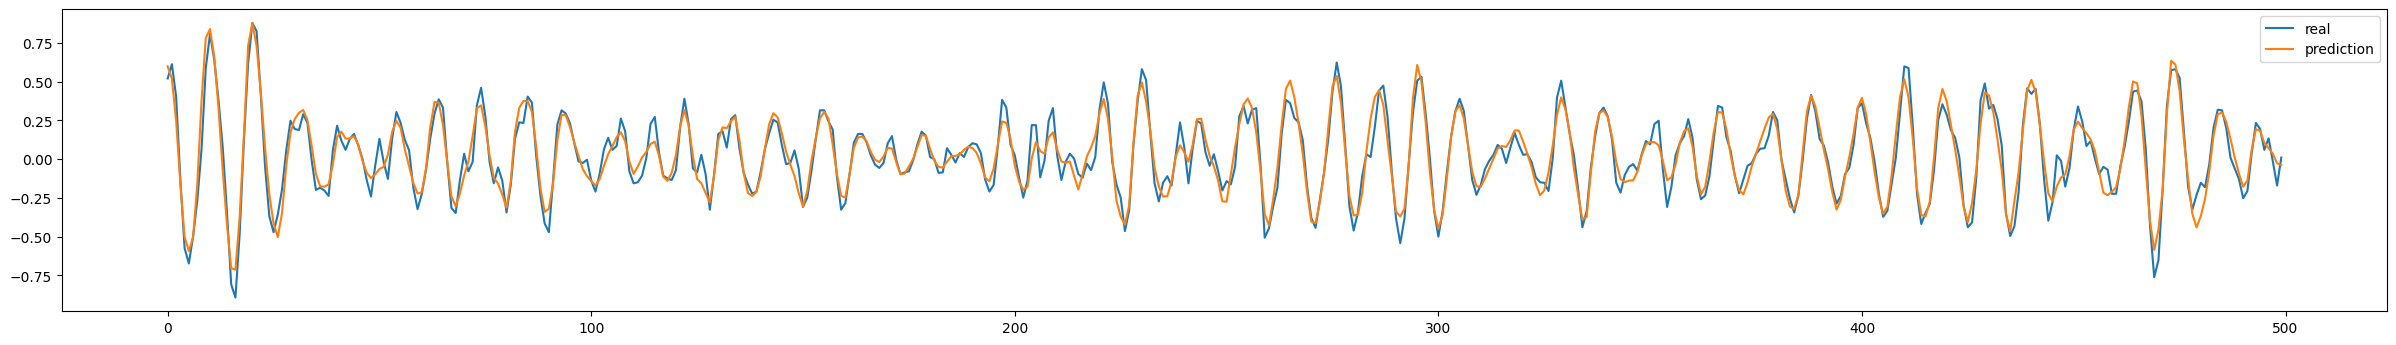

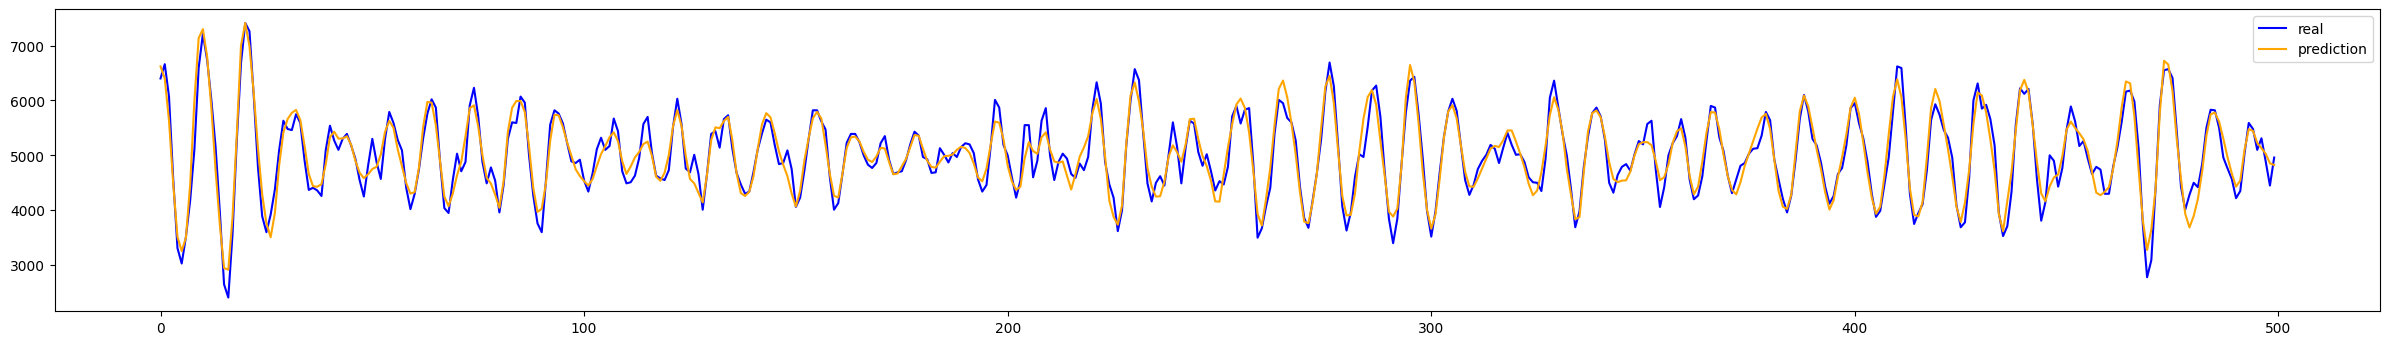

MAE: 178.0771513671875
MAE(sklearn): 178.0771513671875
MAPE(sklearn): 0.03675658577086098
MSE: 51784.79505405903
MSE(sklearn): 51784.79505405903
RMSE(sklearn): 227.56272773470403
Acc: 0.9700950520310772


In [17]:
plt.figure(figsize=(30, 4), dpi=100)
plt.plot(valid50_y_Force1, label = 'real')   #真实曲线
plt.plot(N_pre50_Y_Force1, '-', label = 'prediction') #预测曲线
plt.legend()
plt.show()

fan_force150_real1,fan_force150_pre1 = FanGuiHua_force1(valid50_y_Force1,N_pre50_Y_Force1)

In [18]:
train_heave50_x6, train_heave50_y6, valid_heave50_x6, valid_heave50_y6 = split_train_valid(heave50_x6,heave50_y6, 6600, 7500, 8000)
heave50_model6, heave50_history6, pre_heave50_Y6 = Model_LSTM(train_heave50_x6, train_heave50_y6, valid_heave50_x6, valid_heave50_y6, lr=1.3, epochs=60, batch_size=50)
# train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1 = split_train_valid(heave100_x1,heave100_y1, 6600, 7500, 8000)
# heave100_model1, heave100_history1, pre_heave100_Y1 = Model_LSTM(train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1, lr=1.3, epochs=60, batch_size=50)

train_surge50_x6, train_surge50_y6, valid_surge50_x6, valid_surge50_y6 = split_train_valid(surge50_x6,surge50_y6, 6600, 7500, 8000)
surge50_model6, surge50_history6, pre_surge50_Y6 = Model_LSTM(train_surge50_x6, train_surge50_y6, valid_surge50_x6, valid_surge50_y6, lr=1.3, epochs=60, batch_size=50)
# train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1 = split_train_valid(surge100_x1,surge100_y1, 6600, 7500, 8000)
# surge100_model1, surge100_history1, pre_surge100_Y1 = Model_LSTM(train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1, lr=1.3, epochs=60, batch_size=50)
                                                                 
train_pitch50_x6, train_pitch50_y6, valid_pitch50_x6, valid_pitch50_y6 = split_train_valid(pitch50_x6,pitch50_y6, 6600, 7500, 8000)
pitch50_model6, pitch50_history6, pre_pitch50_Y6 = Model_LSTM(train_pitch50_x6, train_pitch50_y6, valid_pitch50_x6, valid_pitch50_y6, lr=1.3, epochs=60, batch_size=50)
# train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1 = split_train_valid(pitch100_x1,pitch100_y1, 6600, 7500, 8000)
# pitch100_model1, pitch100_history1, pre_pitch100_Y1 = Model_LSTM(train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1, lr=1.3, epochs=60, batch_size=50)

Train on 900 samples, validate on 500 samples
Epoch 1/60
 - 4s - loss: 0.0656 - val_loss: 0.0711
Epoch 2/60
 - 3s - loss: 0.0479 - val_loss: 0.0310
Epoch 3/60
 - 3s - loss: 0.0300 - val_loss: 0.0284
Epoch 4/60
 - 3s - loss: 0.0291 - val_loss: 0.0268
Epoch 5/60
 - 3s - loss: 0.0272 - val_loss: 0.0265
Epoch 6/60
 - 3s - loss: 0.0264 - val_loss: 0.0261
Epoch 7/60
 - 3s - loss: 0.0269 - val_loss: 0.0253
Epoch 8/60
 - 3s - loss: 0.0269 - val_loss: 0.0256
Epoch 9/60
 - 3s - loss: 0.0256 - val_loss: 0.0248
Epoch 10/60
 - 3s - loss: 0.0255 - val_loss: 0.0245
Epoch 11/60
 - 3s - loss: 0.0258 - val_loss: 0.0240
Epoch 12/60
 - 3s - loss: 0.0249 - val_loss: 0.0236
Epoch 13/60
 - 3s - loss: 0.0249 - val_loss: 0.0231
Epoch 14/60
 - 3s - loss: 0.0240 - val_loss: 0.0226
Epoch 15/60
 - 3s - loss: 0.0229 - val_loss: 0.0214
Epoch 16/60
 - 3s - loss: 0.0237 - val_loss: 0.0212
Epoch 17/60
 - 3s - loss: 0.0215 - val_loss: 0.0202
Epoch 18/60
 - 3s - loss: 0.0219 - val_loss: 0.0192
Epoch 19/60
 - 3s - loss: 0

Train on 900 samples, validate on 500 samples
Epoch 1/60
 - 4s - loss: 0.0680 - val_loss: 0.0712
Epoch 2/60
 - 3s - loss: 0.0642 - val_loss: 0.0648
Epoch 3/60
 - 3s - loss: 0.0566 - val_loss: 0.0503
Epoch 4/60
 - 3s - loss: 0.0515 - val_loss: 0.0499
Epoch 5/60
 - 3s - loss: 0.0499 - val_loss: 0.0492
Epoch 6/60
 - 3s - loss: 0.0512 - val_loss: 0.0493
Epoch 7/60
 - 3s - loss: 0.0504 - val_loss: 0.0487
Epoch 8/60
 - 3s - loss: 0.0497 - val_loss: 0.0485
Epoch 9/60
 - 3s - loss: 0.0491 - val_loss: 0.0480
Epoch 10/60
 - 3s - loss: 0.0493 - val_loss: 0.0478
Epoch 11/60
 - 3s - loss: 0.0499 - val_loss: 0.0475
Epoch 12/60
 - 3s - loss: 0.0482 - val_loss: 0.0469
Epoch 13/60
 - 3s - loss: 0.0483 - val_loss: 0.0470
Epoch 14/60
 - 3s - loss: 0.0477 - val_loss: 0.0464
Epoch 15/60
 - 3s - loss: 0.0472 - val_loss: 0.0456
Epoch 16/60
 - 3s - loss: 0.0479 - val_loss: 0.0458
Epoch 17/60
 - 3s - loss: 0.0474 - val_loss: 0.0454
Epoch 18/60
 - 3s - loss: 0.0467 - val_loss: 0.0451
Epoch 19/60
 - 3s - loss: 0

In [19]:
pretrain_heave50_Y6 = heave50_model6.predict(train_heave50_x6)
# pretrain_heave100_Y6 = heave100_model6.predict(train_heave100_x6)

pretrain_surge50_Y6 = surge50_model6.predict(train_surge50_x6)
# pretrain_surge100_Y6 = surge100_model6.predict(train_surge100_x6)

pretrain_pitch50_Y6 = pitch50_model6.predict(train_pitch50_x6)
# pretrain_pitch100_Y6 = pitch100_model6.predict(train_pitch100_x6)

In [41]:
# 输入50步长输出6步长
force150_scaled6 = deal_data1(np.hstack((Heave,Surge,Pitch,Force1))[345:,:], 4, 55)
force150_x6,force150_y6 = split_sequence(force150_scaled6, 50)
# print(force150_x6.shape)
# 输入100步长输出6步长
# force1100_scaled6 = deal_data1(np.hstack((Heave,Surge,Pitch,Force1))[295:,:], 4, 105)
# force1100_x6,force1100_y6 = split_sequence(force1100_scaled6, 100)
# print(force1100_x6.shape)

In [49]:
print(force150_scaled6)

[[ 0.29323308 -0.2055788   0.04503527  0.13829787  0.30141844]
 [ 0.38571429  0.08228731 -0.10991861  0.28014184  0.23049645]
 [ 0.28421053  0.11073919 -0.26858383  0.19148936  0.07092199]
 ...
 [-0.03007519 -0.12273361  0.02767227 -0.0212766   0.4929078 ]
 [ 0.13774436  0.06973501  0.19587629  0.20921986  0.58865248]
 [ 0.22706767  0.01589958  0.01465003  0.18439716  0.38652482]]


In [50]:
print(force150_x6)

[[[ 0.29323308 -0.2055788   0.04503527  0.13829787]
  [ 0.38571429  0.08228731 -0.10991861  0.28014184]
  [ 0.28421053  0.11073919 -0.26858383  0.19148936]
  ...
  [ 0.10917293 -0.02566248 -0.52143245 -0.0177305 ]
  [-0.0962406   0.02426778 -0.29354314 -0.06382979]
  [-0.19097744 -0.21785216 -0.00488334 -0.15602837]]

 [[ 0.38571429  0.08228731 -0.10991861  0.28014184]
  [ 0.28421053  0.11073919 -0.26858383  0.19148936]
  [ 0.08947519 -0.13224547 -0.43678785 -0.05673759]
  ...
  [-0.0962406   0.02426778 -0.29354314 -0.06382979]
  [-0.19097744 -0.21785216 -0.00488334 -0.15602837]
  [-0.14661654 -0.32635983  0.07433532 -0.16312057]]

 [[ 0.28421053  0.11073919 -0.26858383  0.19148936]
  [ 0.08947519 -0.13224547 -0.43678785 -0.05673759]
  [-0.09849624 -0.1707113  -0.34997287 -0.15248227]
  ...
  [-0.19097744 -0.21785216 -0.00488334 -0.15602837]
  [-0.14661654 -0.32635983  0.07433532 -0.16312057]
  [-0.05714286 -0.30906555 -0.08366793 -0.14184397]]

 ...

 [[-0.06842105 -0.05690377 -0.5149

In [51]:
train_force150_x6, train_force150_y6, valid_force150_x6, valid_force150_y6 = split_train_valid(force150_x6,force150_y6, 6600, 7500, 8000)
train50_x_Force6, valid50_x_Force6 = np.hstack((pretrain_heave50_Y6, pretrain_surge50_Y6, pretrain_pitch50_Y6)), np.hstack((pre_heave50_Y6, pre_surge50_Y6, pre_pitch50_Y6))
train50_y_Force6, valid50_y_Force6 = train_force150_y6, valid_force150_y6

In [62]:
print(train50_y_Force6.shape)
print(valid50_y_Force6.shape)

(900, 1)
(500, 1)


In [54]:
N_model50_Force6, N_history50_Force6, N_pre50_train_Y_Force6, N_pre50_Y_Force6 = Model_NN(train50_x_Force6, train50_y_Force6, valid50_x_Force6, valid50_y_Force6, lr=0.01, epochs=1000, batch_size=256)

Train on 900 samples, validate on 500 samples
Epoch 1/1000
 - 0s - loss: 0.0303 - val_loss: 0.0273
Epoch 2/1000
 - 0s - loss: 0.0193 - val_loss: 0.0203
Epoch 3/1000
 - 0s - loss: 0.0177 - val_loss: 0.0182
Epoch 4/1000
 - 0s - loss: 0.0145 - val_loss: 0.0151
Epoch 5/1000
 - 0s - loss: 0.0147 - val_loss: 0.0153
Epoch 6/1000
 - 0s - loss: 0.0137 - val_loss: 0.0148
Epoch 7/1000
 - 0s - loss: 0.0134 - val_loss: 0.0157
Epoch 8/1000
 - 0s - loss: 0.0136 - val_loss: 0.0150
Epoch 9/1000
 - 0s - loss: 0.0134 - val_loss: 0.0147
Epoch 10/1000
 - 0s - loss: 0.0132 - val_loss: 0.0144
Epoch 11/1000
 - 0s - loss: 0.0131 - val_loss: 0.0146
Epoch 12/1000
 - 0s - loss: 0.0132 - val_loss: 0.0145
Epoch 13/1000
 - 0s - loss: 0.0131 - val_loss: 0.0146
Epoch 14/1000
 - 0s - loss: 0.0131 - val_loss: 0.0146
Epoch 15/1000
 - 0s - loss: 0.0131 - val_loss: 0.0146
Epoch 16/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 17/1000
 - 0s - loss: 0.0131 - val_loss: 0.0144
Epoch 18/1000
 - 0s - loss: 0.0131 - val_loss

Epoch 152/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 153/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 154/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 155/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 156/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 157/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 158/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 159/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 160/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 161/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 162/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 163/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 164/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 165/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 166/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 167/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 168/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 169/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 170/

Epoch 301/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 302/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 303/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 304/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 305/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 306/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 307/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 308/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 309/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 310/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 311/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 312/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 313/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 314/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 315/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 316/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 317/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 318/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 319/

Epoch 450/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 451/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 452/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 453/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 454/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 455/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 456/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 457/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 458/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 459/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 460/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 461/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 462/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 463/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 464/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 465/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 466/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 467/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 468/

Epoch 599/1000
 - 0s - loss: 0.0130 - val_loss: 0.0147
Epoch 600/1000
 - 0s - loss: 0.0130 - val_loss: 0.0147
Epoch 601/1000
 - 0s - loss: 0.0130 - val_loss: 0.0147
Epoch 602/1000
 - 0s - loss: 0.0130 - val_loss: 0.0147
Epoch 603/1000
 - 0s - loss: 0.0130 - val_loss: 0.0147
Epoch 604/1000
 - 0s - loss: 0.0130 - val_loss: 0.0147
Epoch 605/1000
 - 0s - loss: 0.0130 - val_loss: 0.0147
Epoch 606/1000
 - 0s - loss: 0.0130 - val_loss: 0.0147
Epoch 607/1000
 - 0s - loss: 0.0130 - val_loss: 0.0147
Epoch 608/1000
 - 0s - loss: 0.0130 - val_loss: 0.0147
Epoch 609/1000
 - 0s - loss: 0.0130 - val_loss: 0.0147
Epoch 610/1000
 - 0s - loss: 0.0130 - val_loss: 0.0147
Epoch 611/1000
 - 0s - loss: 0.0130 - val_loss: 0.0147
Epoch 612/1000
 - 0s - loss: 0.0130 - val_loss: 0.0147
Epoch 613/1000
 - 0s - loss: 0.0130 - val_loss: 0.0147
Epoch 614/1000
 - 0s - loss: 0.0130 - val_loss: 0.0147
Epoch 615/1000
 - 0s - loss: 0.0130 - val_loss: 0.0147
Epoch 616/1000
 - 0s - loss: 0.0130 - val_loss: 0.0147
Epoch 617/

Epoch 748/1000
 - 0s - loss: 0.0128 - val_loss: 0.0144
Epoch 749/1000
 - 0s - loss: 0.0128 - val_loss: 0.0144
Epoch 750/1000
 - 0s - loss: 0.0128 - val_loss: 0.0144
Epoch 751/1000
 - 0s - loss: 0.0128 - val_loss: 0.0144
Epoch 752/1000
 - 0s - loss: 0.0128 - val_loss: 0.0144
Epoch 753/1000
 - 0s - loss: 0.0128 - val_loss: 0.0144
Epoch 754/1000
 - 0s - loss: 0.0128 - val_loss: 0.0144
Epoch 755/1000
 - 0s - loss: 0.0128 - val_loss: 0.0144
Epoch 756/1000
 - 0s - loss: 0.0128 - val_loss: 0.0144
Epoch 757/1000
 - 0s - loss: 0.0128 - val_loss: 0.0144
Epoch 758/1000
 - 0s - loss: 0.0128 - val_loss: 0.0144
Epoch 759/1000
 - 0s - loss: 0.0128 - val_loss: 0.0144
Epoch 760/1000
 - 0s - loss: 0.0128 - val_loss: 0.0144
Epoch 761/1000
 - 0s - loss: 0.0128 - val_loss: 0.0144
Epoch 762/1000
 - 0s - loss: 0.0128 - val_loss: 0.0144
Epoch 763/1000
 - 0s - loss: 0.0128 - val_loss: 0.0144
Epoch 764/1000
 - 0s - loss: 0.0128 - val_loss: 0.0144
Epoch 765/1000
 - 0s - loss: 0.0128 - val_loss: 0.0144
Epoch 766/

Epoch 897/1000
 - 0s - loss: 0.0127 - val_loss: 0.0145
Epoch 898/1000
 - 0s - loss: 0.0127 - val_loss: 0.0145
Epoch 899/1000
 - 0s - loss: 0.0127 - val_loss: 0.0145
Epoch 900/1000
 - 0s - loss: 0.0127 - val_loss: 0.0145
Epoch 901/1000
 - 0s - loss: 0.0127 - val_loss: 0.0145
Epoch 902/1000
 - 0s - loss: 0.0127 - val_loss: 0.0145
Epoch 903/1000
 - 0s - loss: 0.0127 - val_loss: 0.0145
Epoch 904/1000
 - 0s - loss: 0.0127 - val_loss: 0.0145
Epoch 905/1000
 - 0s - loss: 0.0127 - val_loss: 0.0145
Epoch 906/1000
 - 0s - loss: 0.0127 - val_loss: 0.0145
Epoch 907/1000
 - 0s - loss: 0.0127 - val_loss: 0.0145
Epoch 908/1000
 - 0s - loss: 0.0127 - val_loss: 0.0145
Epoch 909/1000
 - 0s - loss: 0.0127 - val_loss: 0.0145
Epoch 910/1000
 - 0s - loss: 0.0127 - val_loss: 0.0145
Epoch 911/1000
 - 0s - loss: 0.0127 - val_loss: 0.0145
Epoch 912/1000
 - 0s - loss: 0.0127 - val_loss: 0.0145
Epoch 913/1000
 - 0s - loss: 0.0127 - val_loss: 0.0145
Epoch 914/1000
 - 0s - loss: 0.0127 - val_loss: 0.0145
Epoch 915/

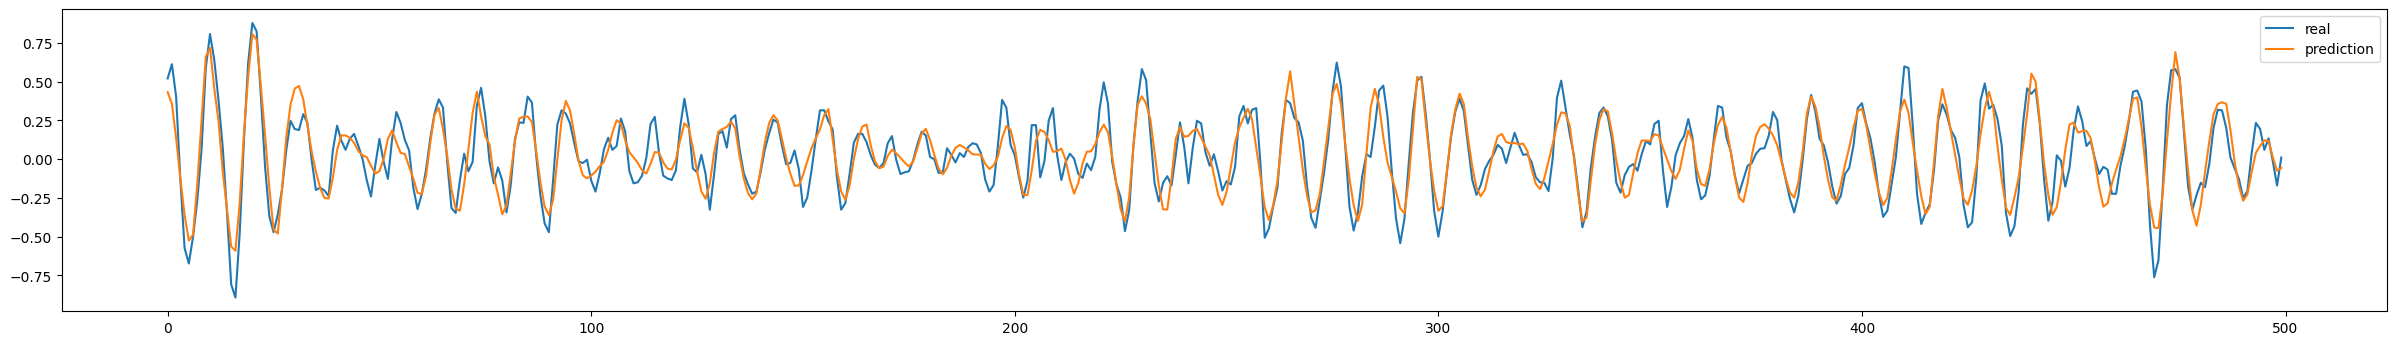

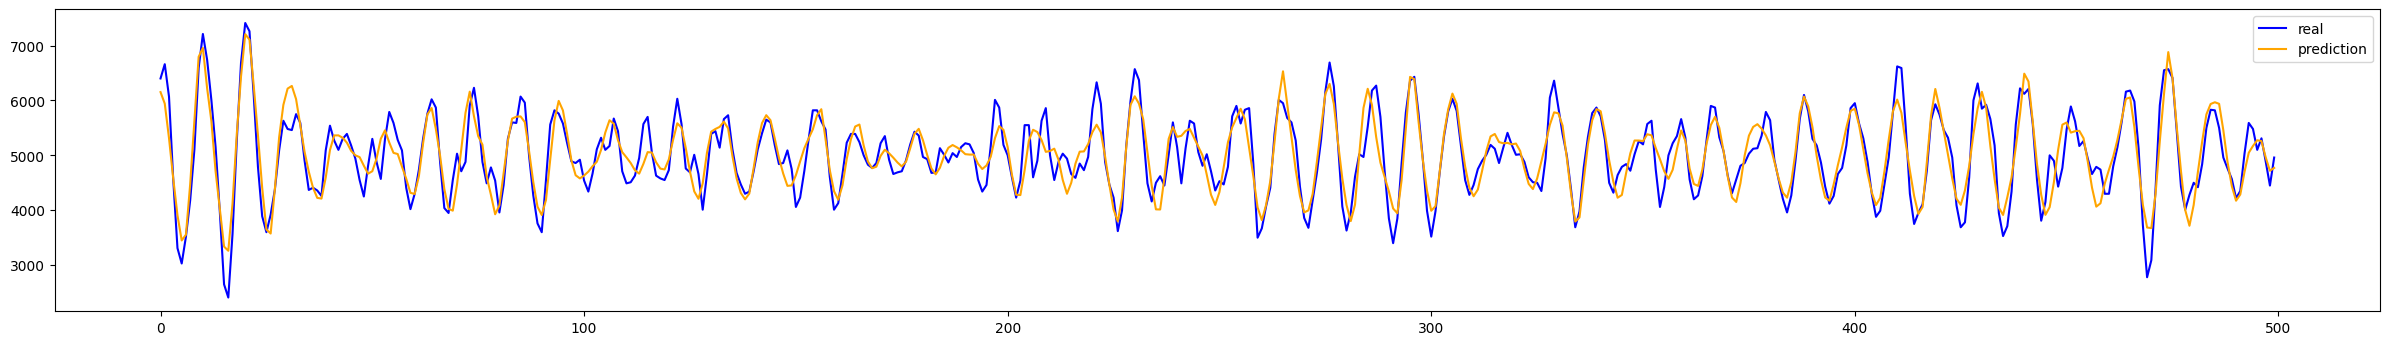

MAE: 270.1531044921875
MAE(sklearn): 270.1531044921875
MAPE(sklearn): 0.05589208207537012
MSE: 116212.77165460419
MSE(sklearn): 116212.77165460419
RMSE(sklearn): 340.89994375858174
Acc: 0.8950418547709449


In [55]:
plt.figure(figsize=(30, 4), dpi=100)
plt.plot(valid50_y_Force6, label = 'real')   #真实曲线
plt.plot(N_pre50_Y_Force6, '-', label = 'prediction') #预测曲线
plt.legend()
plt.show()

fan_force150_real6,fan_force150_pre6 = FanGuiHua_force1(valid50_y_Force6,N_pre50_Y_Force6)

In [56]:
# 输入50步长输出6步长
force150_scaled6 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[345:,:], 4, 55)
force150_x6,force150_y6 = split_sequence(force150_scaled6, 50)
# print(force150_x6.shape)
# 输入100步长输出6步长
# force1100_scaled6 = deal_data1(np.hstack((Heave,Surge,Pitch,Force1))[295:,:], 4, 105)
# force1100_x6,force1100_y6 = split_sequence(force1100_scaled6, 100)
# print(force1100_x6.shape)

In [57]:
print(force150_scaled6)

[[ 0.29323308 -0.2055788   0.04503527  0.30141844]
 [ 0.38571429  0.08228731 -0.10991861  0.23049645]
 [ 0.28421053  0.11073919 -0.26858383  0.07092199]
 ...
 [-0.03007519 -0.12273361  0.02767227  0.4929078 ]
 [ 0.13774436  0.06973501  0.19587629  0.58865248]
 [ 0.22706767  0.01589958  0.01465003  0.38652482]]


In [58]:
train_force150_x6, train_force150_y6, valid_force150_x6, valid_force150_y6 = split_train_valid(force150_x6,force150_y6, 6600, 7500, 8000)
train50_x_Force6, valid50_x_Force6 = np.hstack((pretrain_heave50_Y6, pretrain_surge50_Y6, pretrain_pitch50_Y6)), np.hstack((pre_heave50_Y6, pre_surge50_Y6, pre_pitch50_Y6))
train50_y_Force6, valid50_y_Force6 = train_force150_y6, valid_force150_y6

In [59]:
N_model50_Force6, N_history50_Force6, N_pre50_train_Y_Force6, N_pre50_Y_Force6 = Model_NN(train50_x_Force6, train50_y_Force6, valid50_x_Force6, valid50_y_Force6, lr=0.01, epochs=1000, batch_size=256)

Train on 900 samples, validate on 500 samples
Epoch 1/1000
 - 0s - loss: 0.0246 - val_loss: 0.0227
Epoch 2/1000
 - 0s - loss: 0.0166 - val_loss: 0.0207
Epoch 3/1000
 - 0s - loss: 0.0168 - val_loss: 0.0151
Epoch 4/1000
 - 0s - loss: 0.0141 - val_loss: 0.0159
Epoch 5/1000
 - 0s - loss: 0.0142 - val_loss: 0.0146
Epoch 6/1000
 - 0s - loss: 0.0133 - val_loss: 0.0162
Epoch 7/1000
 - 0s - loss: 0.0139 - val_loss: 0.0148
Epoch 8/1000
 - 0s - loss: 0.0132 - val_loss: 0.0145
Epoch 9/1000
 - 0s - loss: 0.0133 - val_loss: 0.0144
Epoch 10/1000
 - 0s - loss: 0.0131 - val_loss: 0.0147
Epoch 11/1000
 - 0s - loss: 0.0132 - val_loss: 0.0147
Epoch 12/1000
 - 0s - loss: 0.0132 - val_loss: 0.0145
Epoch 13/1000
 - 0s - loss: 0.0131 - val_loss: 0.0144
Epoch 14/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 15/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 16/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 17/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 18/1000
 - 0s - loss: 0.0131 - val_loss

 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 152/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 153/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 154/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 155/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 156/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 157/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 158/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 159/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 160/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 161/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 162/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 163/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 164/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 165/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 166/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 167/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 168/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 169/1000
 - 0s - lo

 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 301/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 302/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 303/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 304/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 305/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 306/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 307/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 308/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 309/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 310/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 311/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 312/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 313/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 314/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 315/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 316/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 317/1000
 - 0s - loss: 0.0131 - val_loss: 0.0145
Epoch 318/1000
 - 0s - lo

Epoch 450/1000
 - 0s - loss: 0.0129 - val_loss: 0.0143
Epoch 451/1000
 - 0s - loss: 0.0129 - val_loss: 0.0143
Epoch 452/1000
 - 0s - loss: 0.0129 - val_loss: 0.0143
Epoch 453/1000
 - 0s - loss: 0.0129 - val_loss: 0.0143
Epoch 454/1000
 - 0s - loss: 0.0129 - val_loss: 0.0143
Epoch 455/1000
 - 0s - loss: 0.0129 - val_loss: 0.0143
Epoch 456/1000
 - 0s - loss: 0.0129 - val_loss: 0.0143
Epoch 457/1000
 - 0s - loss: 0.0129 - val_loss: 0.0143
Epoch 458/1000
 - 0s - loss: 0.0129 - val_loss: 0.0143
Epoch 459/1000
 - 0s - loss: 0.0129 - val_loss: 0.0143
Epoch 460/1000
 - 0s - loss: 0.0128 - val_loss: 0.0143
Epoch 461/1000
 - 0s - loss: 0.0128 - val_loss: 0.0143
Epoch 462/1000
 - 0s - loss: 0.0128 - val_loss: 0.0143
Epoch 463/1000
 - 0s - loss: 0.0128 - val_loss: 0.0143
Epoch 464/1000
 - 0s - loss: 0.0128 - val_loss: 0.0143
Epoch 465/1000
 - 0s - loss: 0.0128 - val_loss: 0.0143
Epoch 466/1000
 - 0s - loss: 0.0128 - val_loss: 0.0143
Epoch 467/1000
 - 0s - loss: 0.0128 - val_loss: 0.0143
Epoch 468/

Epoch 599/1000
 - 0s - loss: 0.0128 - val_loss: 0.0144
Epoch 600/1000
 - 0s - loss: 0.0128 - val_loss: 0.0144
Epoch 601/1000
 - 0s - loss: 0.0128 - val_loss: 0.0144
Epoch 602/1000
 - 0s - loss: 0.0128 - val_loss: 0.0144
Epoch 603/1000
 - 0s - loss: 0.0128 - val_loss: 0.0144
Epoch 604/1000
 - 0s - loss: 0.0128 - val_loss: 0.0144
Epoch 605/1000
 - 0s - loss: 0.0128 - val_loss: 0.0144
Epoch 606/1000
 - 0s - loss: 0.0128 - val_loss: 0.0144
Epoch 607/1000
 - 0s - loss: 0.0128 - val_loss: 0.0144
Epoch 608/1000
 - 0s - loss: 0.0128 - val_loss: 0.0144
Epoch 609/1000
 - 0s - loss: 0.0128 - val_loss: 0.0144
Epoch 610/1000
 - 0s - loss: 0.0128 - val_loss: 0.0144
Epoch 611/1000
 - 0s - loss: 0.0128 - val_loss: 0.0144
Epoch 612/1000
 - 0s - loss: 0.0128 - val_loss: 0.0144
Epoch 613/1000
 - 0s - loss: 0.0128 - val_loss: 0.0144
Epoch 614/1000
 - 0s - loss: 0.0128 - val_loss: 0.0144
Epoch 615/1000
 - 0s - loss: 0.0128 - val_loss: 0.0144
Epoch 616/1000
 - 0s - loss: 0.0128 - val_loss: 0.0144
Epoch 617/

Epoch 748/1000
 - 0s - loss: 0.0127 - val_loss: 0.0145
Epoch 749/1000
 - 0s - loss: 0.0127 - val_loss: 0.0145
Epoch 750/1000
 - 0s - loss: 0.0127 - val_loss: 0.0145
Epoch 751/1000
 - 0s - loss: 0.0127 - val_loss: 0.0145
Epoch 752/1000
 - 0s - loss: 0.0127 - val_loss: 0.0145
Epoch 753/1000
 - 0s - loss: 0.0127 - val_loss: 0.0145
Epoch 754/1000
 - 0s - loss: 0.0127 - val_loss: 0.0145
Epoch 755/1000
 - 0s - loss: 0.0127 - val_loss: 0.0145
Epoch 756/1000
 - 0s - loss: 0.0127 - val_loss: 0.0145
Epoch 757/1000
 - 0s - loss: 0.0127 - val_loss: 0.0145
Epoch 758/1000
 - 0s - loss: 0.0127 - val_loss: 0.0145
Epoch 759/1000
 - 0s - loss: 0.0127 - val_loss: 0.0145
Epoch 760/1000
 - 0s - loss: 0.0127 - val_loss: 0.0145
Epoch 761/1000
 - 0s - loss: 0.0127 - val_loss: 0.0145
Epoch 762/1000
 - 0s - loss: 0.0127 - val_loss: 0.0145
Epoch 763/1000
 - 0s - loss: 0.0127 - val_loss: 0.0145
Epoch 764/1000
 - 0s - loss: 0.0127 - val_loss: 0.0145
Epoch 765/1000
 - 0s - loss: 0.0127 - val_loss: 0.0145
Epoch 766/

Epoch 897/1000
 - 0s - loss: 0.0127 - val_loss: 0.0146
Epoch 898/1000
 - 0s - loss: 0.0127 - val_loss: 0.0146
Epoch 899/1000
 - 0s - loss: 0.0127 - val_loss: 0.0146
Epoch 900/1000
 - 0s - loss: 0.0127 - val_loss: 0.0146
Epoch 901/1000
 - 0s - loss: 0.0127 - val_loss: 0.0146
Epoch 902/1000
 - 0s - loss: 0.0127 - val_loss: 0.0146
Epoch 903/1000
 - 0s - loss: 0.0127 - val_loss: 0.0146
Epoch 904/1000
 - 0s - loss: 0.0127 - val_loss: 0.0146
Epoch 905/1000
 - 0s - loss: 0.0127 - val_loss: 0.0146
Epoch 906/1000
 - 0s - loss: 0.0127 - val_loss: 0.0146
Epoch 907/1000
 - 0s - loss: 0.0127 - val_loss: 0.0146
Epoch 908/1000
 - 0s - loss: 0.0127 - val_loss: 0.0146
Epoch 909/1000
 - 0s - loss: 0.0127 - val_loss: 0.0146
Epoch 910/1000
 - 0s - loss: 0.0127 - val_loss: 0.0146
Epoch 911/1000
 - 0s - loss: 0.0127 - val_loss: 0.0146
Epoch 912/1000
 - 0s - loss: 0.0127 - val_loss: 0.0146
Epoch 913/1000
 - 0s - loss: 0.0127 - val_loss: 0.0146
Epoch 914/1000
 - 0s - loss: 0.0127 - val_loss: 0.0146
Epoch 915/

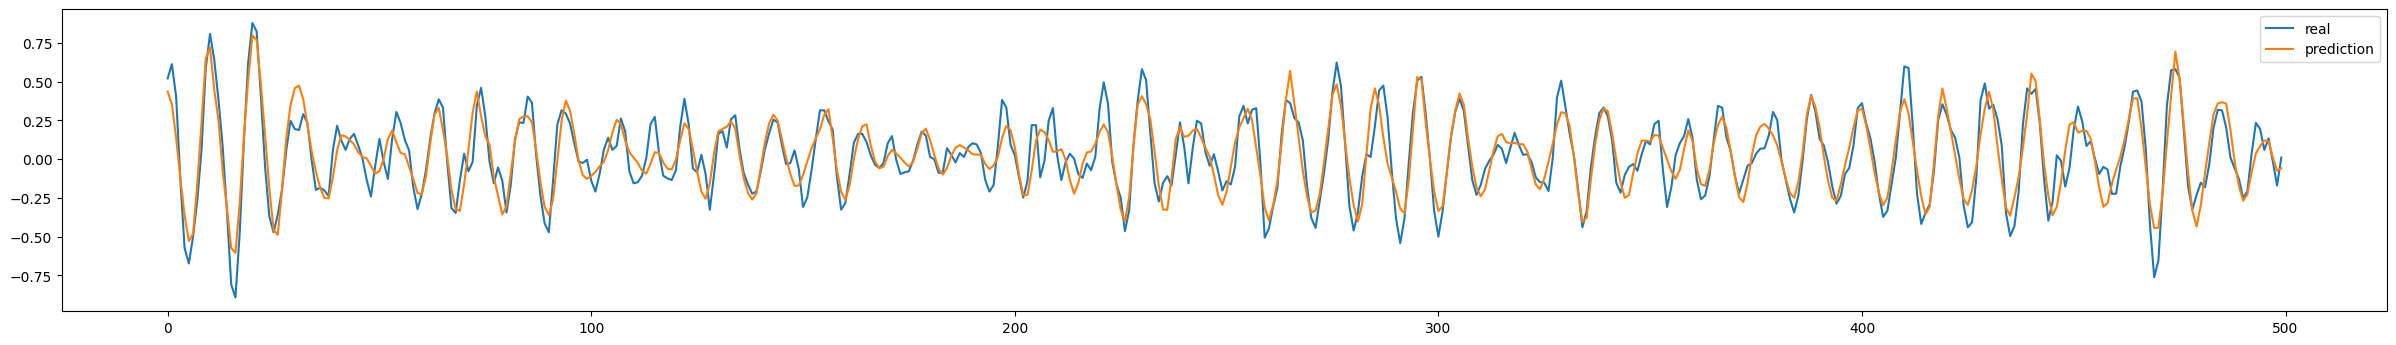

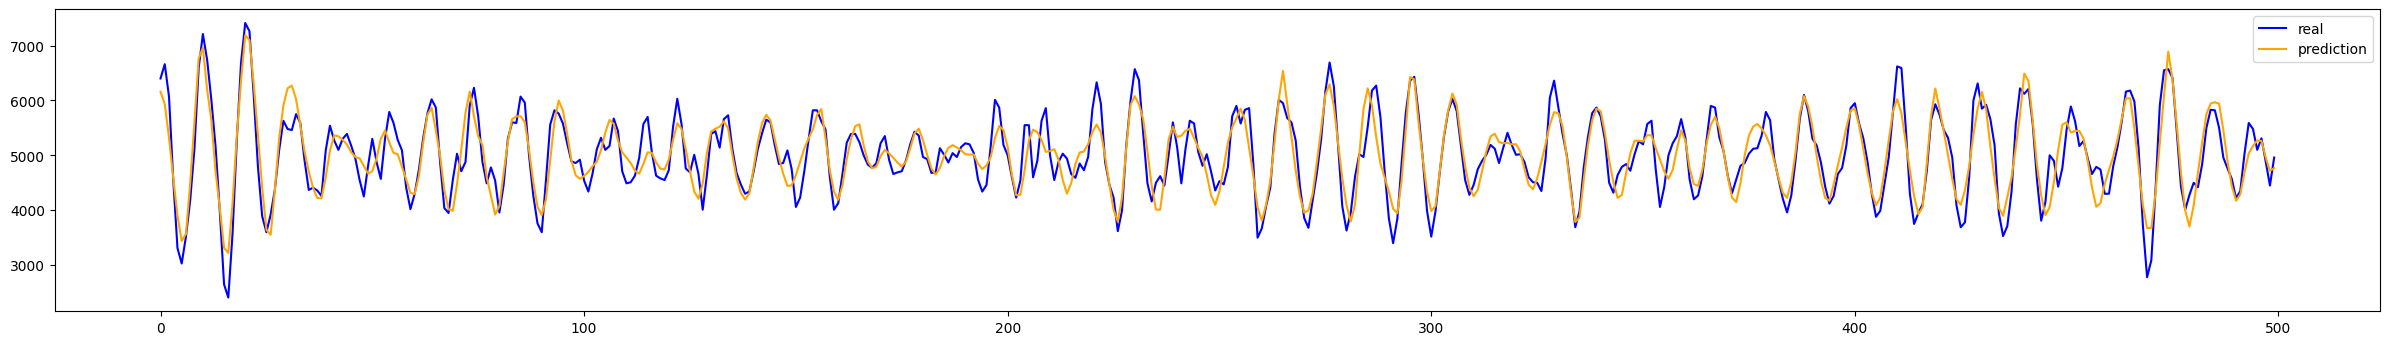

MAE: 270.22204150390627
MAE(sklearn): 270.22204150390627
MAPE(sklearn): 0.05582042964902088
MSE: 116291.6473678037
MSE(sklearn): 116291.6473678037
RMSE(sklearn): 341.0156116188872
Acc: 0.8939891019086468


In [60]:
plt.figure(figsize=(30, 4), dpi=100)
plt.plot(valid50_y_Force6, label = 'real')   #真实曲线
plt.plot(N_pre50_Y_Force6, '-', label = 'prediction') #预测曲线
plt.legend()
plt.show()

fan_force150_real6,fan_force150_pre6 = FanGuiHua_force1(valid50_y_Force6,N_pre50_Y_Force6)

#### 过去预测未来1（未来6步），未来1（未来6步）预测未来2（未来6步后的6步）

In [64]:
print(train50_x_Force6.shape)
print(valid50_x_Force6.shape)
print(train50_y_Force6.shape)
print(valid50_y_Force6.shape)

(900, 3)
(500, 3)
(900, 1)
(500, 1)


In [67]:
a1=np.hstack((train50_x_Force6, train50_y_Force6))
a2=np.hstack((valid50_x_Force6, valid50_y_Force6))
b=np.vstack((a1,a2))

In [71]:
print(b.shape)

# 输入50步长输出6步长
future_force150_scaled6 = deal_data2(b[345:,:], 4, 55)
future_force150_x6,future_force150_y6 = split_sequence(future_force150_scaled6, 50)
print(future_force150_x6.shape)
print(future_force150_y6.shape)

(1400, 4)
(951, 50, 3)
(951,)


In [75]:
future_train_force50_x6, future_train_force50_y6, future_valid_force50_x6, future_valid_force50_y6 = split_train_valid(future_force150_x6,future_force150_y6, 0, 600, 951)

future_force50_model6, future_force50_history6, future_pre_force50_Y6 = Model_LSTM(future_train_force50_x6, future_train_force50_y6, future_valid_force50_x6, future_valid_force50_y6, lr=1.3, epochs=60, batch_size=50)

Train on 600 samples, validate on 351 samples
Epoch 1/60
 - 3s - loss: 0.0634 - val_loss: 0.0514
Epoch 2/60
 - 2s - loss: 0.0571 - val_loss: 0.0444
Epoch 3/60
 - 2s - loss: 0.0463 - val_loss: 0.0328
Epoch 4/60
 - 2s - loss: 0.0372 - val_loss: 0.0304
Epoch 5/60
 - 2s - loss: 0.0359 - val_loss: 0.0294
Epoch 6/60
 - 2s - loss: 0.0350 - val_loss: 0.0292
Epoch 7/60
 - 2s - loss: 0.0349 - val_loss: 0.0292
Epoch 8/60
 - 2s - loss: 0.0350 - val_loss: 0.0291
Epoch 9/60
 - 2s - loss: 0.0346 - val_loss: 0.0290
Epoch 10/60
 - 2s - loss: 0.0336 - val_loss: 0.0290
Epoch 11/60
 - 2s - loss: 0.0337 - val_loss: 0.0290
Epoch 12/60
 - 2s - loss: 0.0350 - val_loss: 0.0289
Epoch 13/60
 - 2s - loss: 0.0346 - val_loss: 0.0289
Epoch 14/60
 - 2s - loss: 0.0339 - val_loss: 0.0289
Epoch 15/60
 - 2s - loss: 0.0336 - val_loss: 0.0288
Epoch 16/60
 - 2s - loss: 0.0339 - val_loss: 0.0289
Epoch 17/60
 - 2s - loss: 0.0335 - val_loss: 0.0288
Epoch 18/60
 - 2s - loss: 0.0335 - val_loss: 0.0288
Epoch 19/60
 - 2s - loss: 0

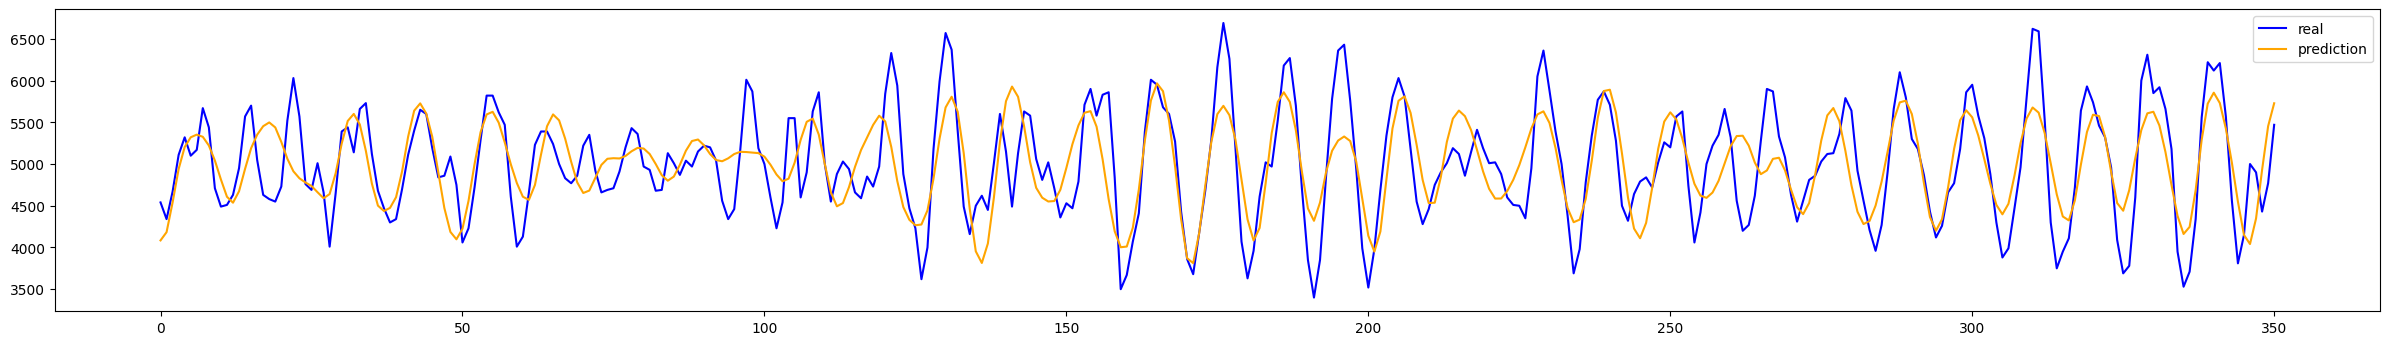

MAE: 380.34790386841166
MAE(sklearn): 380.34790386841166
MAPE(sklearn): 0.07761225512591324
MSE: 218033.89457703315
MSE(sklearn): 218033.89457703315
RMSE(sklearn): 466.9409968904349
Acc: 0.6786969013282891


In [77]:
# plt.figure(figsize=(30, 4), dpi=100)
# plt.plot(future_valid_force50_y6, label = 'real')   #真实曲线
# plt.plot(future_pre_force50_Y6, '-', label = 'prediction') #预测曲线
# plt.legend()
# plt.show()

future_fan_force150_real6,future_fan_force150_pre6 = FanGuiHua_force1(future_valid_force50_y6,future_pre_force50_Y6)